In [1]:
import numpy as np
import math
import json
import time
import os
from IPython.display import HTML
from dataclasses import dataclass

from ipynb.fs.full.forcemodel import IForceModel, GravityForce
from ipynb.fs.full.integrator import IIntegrator, SymplecticEuler, VelocityVerlet
from ipynb.fs.full.env import SolarSystemEnv, run_simulation, run_script_simulation, adjust_barycentric
from ipynb.fs.full.vis import visualize_trajectories, plot_static_trajectories
from ipynb.fs.full.helpers import save_states, load_states
from ipynb.fs.full.ship import SimpleImpulseShip, Maneuver, simple_action_space, IShip
from ipynb.fs.full.rlmontecarlo import train_mc, MonteCarloAgent, PolicyNet, compute_returns

In [2]:
@dataclass
class TrainingConfig:
    bodies: list
    dt: float
    max_steps: int
    n_episodes: int
    log_every: int
    log_states: bool
    log_n_entries: int
    ship_index: int
    mass: float
    thrust: float
    actions: object
    safety_radius: float
    escape_dist: float
    escape_vel: float
    target_dist: float
    target_vel: float
    reference_point_index: int
    reward_coef: float

Cool but unstable with really massive suns
bodies = [
    # Masses (kg)
    np.array([
        1.0e31,
        1.0e31,
        1.0e31,
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.97e11, -0.243e11],   
        [-0.97e11, 0.243e11],
        [0.0, 0.0], 
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.466e5, 0.432e5],    
        [0.466e5, 0.432e5],
        [-0.932e5, -0.864e5], 
    ]),
    # Names
    np.array([
        "One",
        "Two",
        "Three",
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "red",        
        "blue",
        "green",
    ]),
]

# Monte Carlo RL with NN-Q Table #

In [3]:
bodies = [
    # Masses
    np.array([
        5.972e24,       # Earth
        7.342e22,       # Luna
        1.0e5,          # Ship
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.0, 0.0],                # Earth
        [3.844e8, 0.0],      # Luna
        [3.6e7, 0.0],        # Ship
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.0, 0.0],                   # Earth
        [0.0, 1022.0],          # Luna
        [0.0, 3055.0],         # Ship
    ]),
    # Names of celestial bodies
    np.array([
        "Earth",
        "Moon",
        "Ship"
    ]),
    # Colors for visuals
    np.array([
        "blue",       # Earth
        "gray",       # Moon (Luna)
        "lightblue",  # Ship
    ]),
]

In [4]:
bodies = [
    # Masses
    np.array([
        5.972e24,       # Earth
        1.0e5,          # Ship
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.0, 0.0],                # Earth
        [2e6, 0.0],        # Ship
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.0, 0.0],                   # Earth
        [0.0, 14000.0],         # Ship
    ]),
    # Names of celestial bodies
    np.array([
        "Earth",
        "Ship"
    ]),
    # Colors for visuals
    np.array([
        "blue",       # Earth
        "lightblue",  # Ship
    ]),
]

dt = 0.1
simulation_time = 3600 * 1 * 1  # seconds
max_steps = int(simulation_time / dt)

ship_index = len(bodies[0])-1
mass = bodies[0][ship_index]
reward_coef = 1.0 / max_steps
thrust = 1e6 / dt

training_config = TrainingConfig(
    bodies=bodies,
    dt=dt,
    max_steps=max_steps,
    n_episodes=4,
    log_every=1,
    log_states=True,
    log_n_entries=400,
    ship_index=ship_index,
    mass=mass,
    thrust=thrust,
    actions=simple_action_space,
    safety_radius=1e5,
    escape_dist=1e8,
    escape_vel=4e5,
    target_dist=4e6,
    target_vel=3055.0,
    reference_point_index=0,
    reward_coef=reward_coef
)

In [5]:
forcemodel = GravityForce
integrator = VelocityVerlet
ship = SimpleImpulseShip
agent = MonteCarloAgent

In [6]:
def run_training(forcemodel: IForceModel, integrator: IIntegrator, iship: IShip, iagent: MonteCarloAgent, training_config: TrainingConfig):
    ship_kwargs = {k: getattr(training_config, k) for k in [
        "ship_index", "mass", "thrust", "actions",
        "safety_radius", "escape_dist", "escape_vel",
        "target_dist", "target_vel", "reference_point_index",
        "reward_coef"
    ]}
    ship = iship(**ship_kwargs)
    
    env = SolarSystemEnv(forcemodel, integrator, bodies=training_config.bodies, ship=ship, dt=training_config.dt)
    
    obs0 = env.reset()
    obs_dim = obs0.shape[0]
    
    agent = iagent(obs_dim, n_actions=training_config.actions.n)
    
    states = train_mc(env, agent, n_episodes=training_config.n_episodes, max_steps=training_config.max_steps, log_every=training_config.log_every, log_states=training_config.log_states, log_n_entries=training_config.log_n_entries)
    return states

In [7]:
#states = run_training(forcemodel, integrator, ship, agent, training_config)

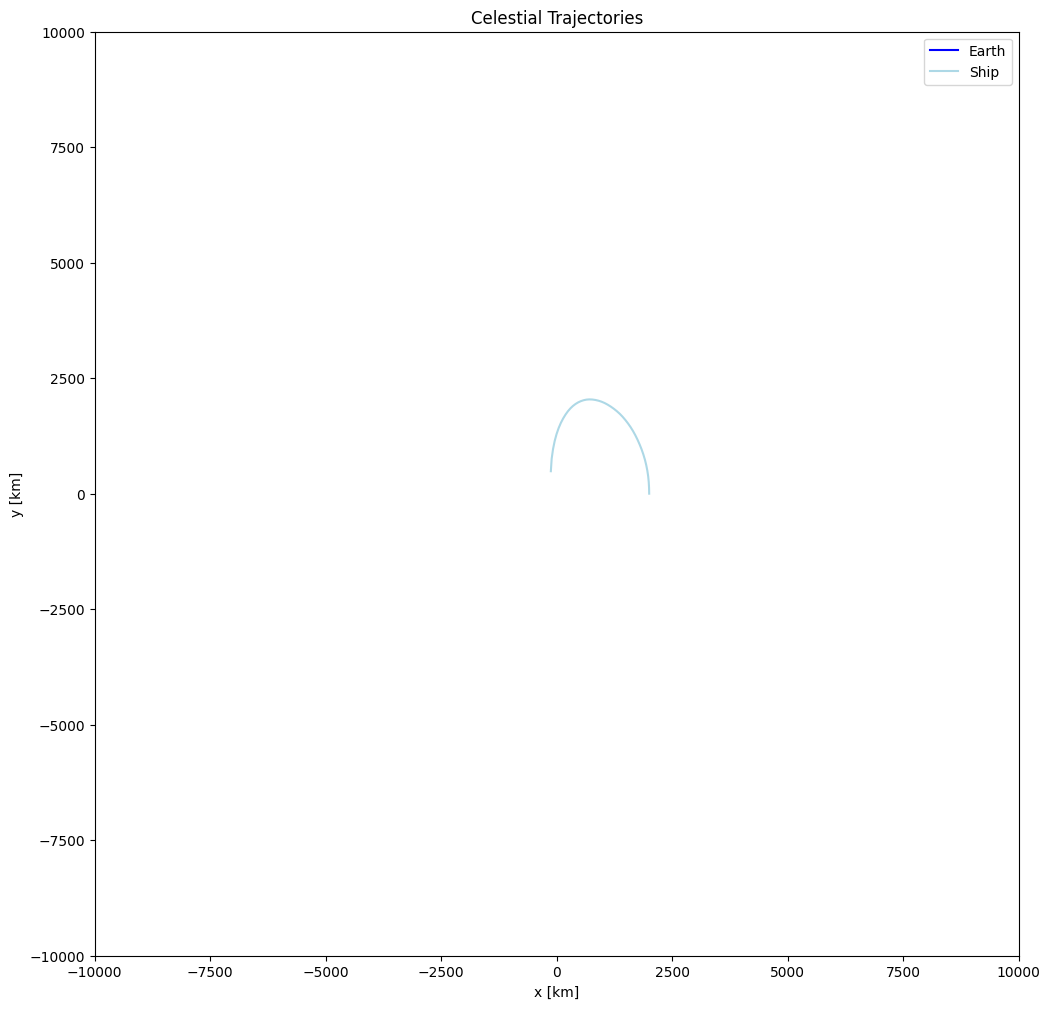

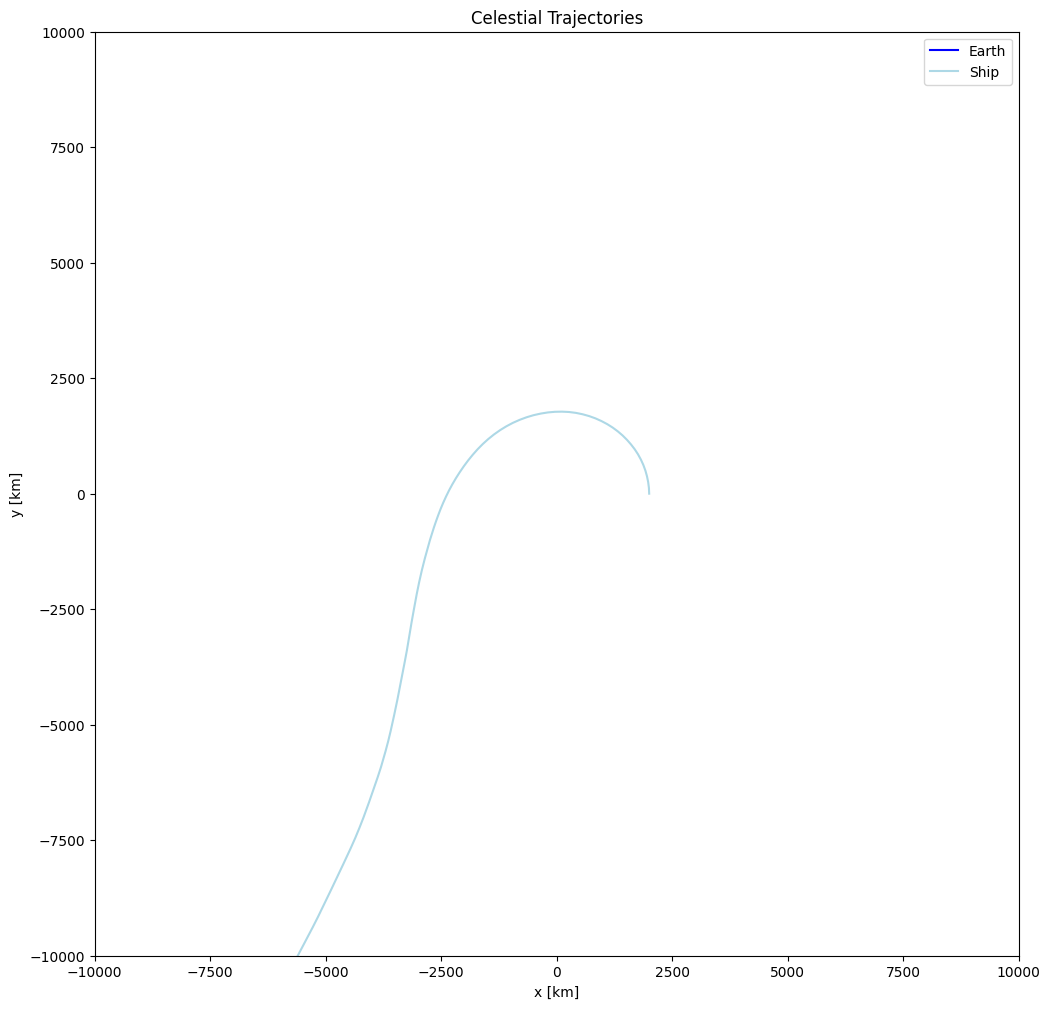

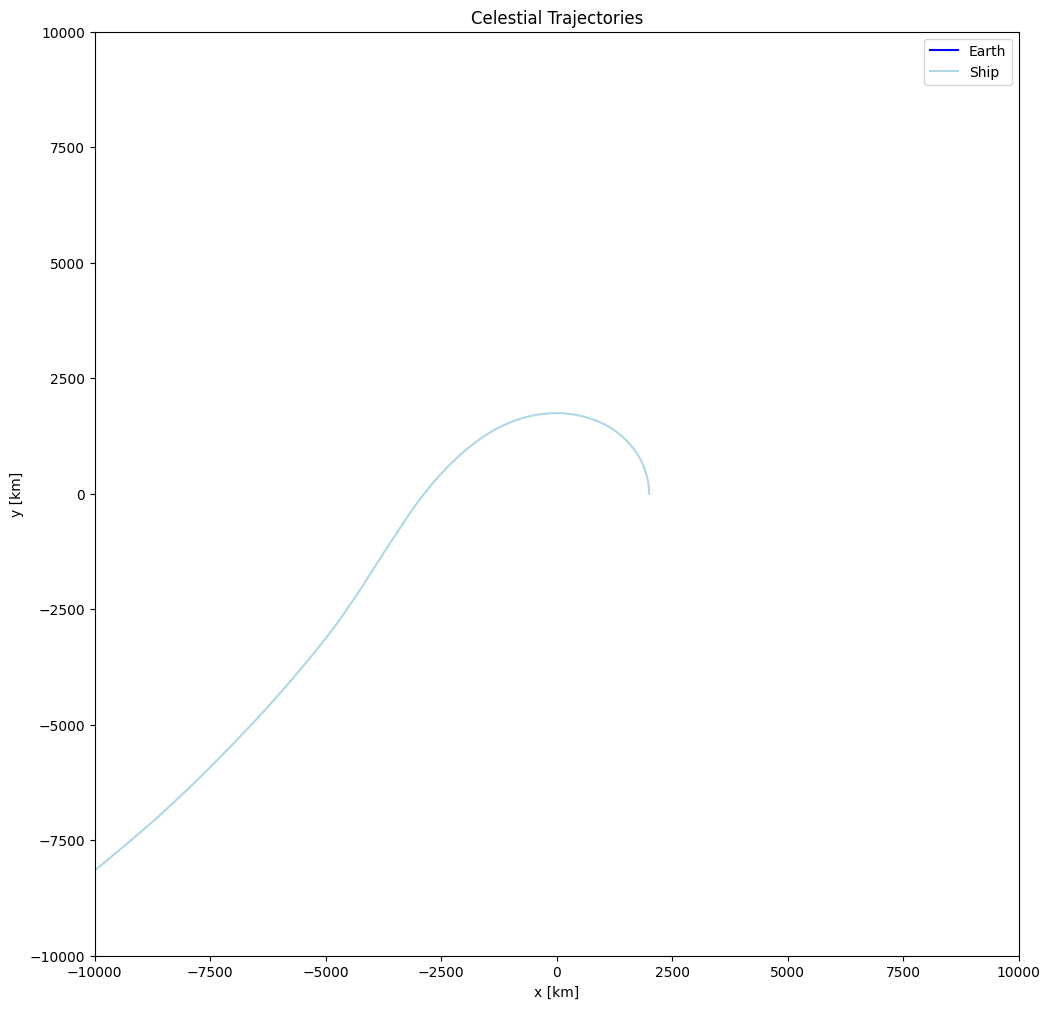

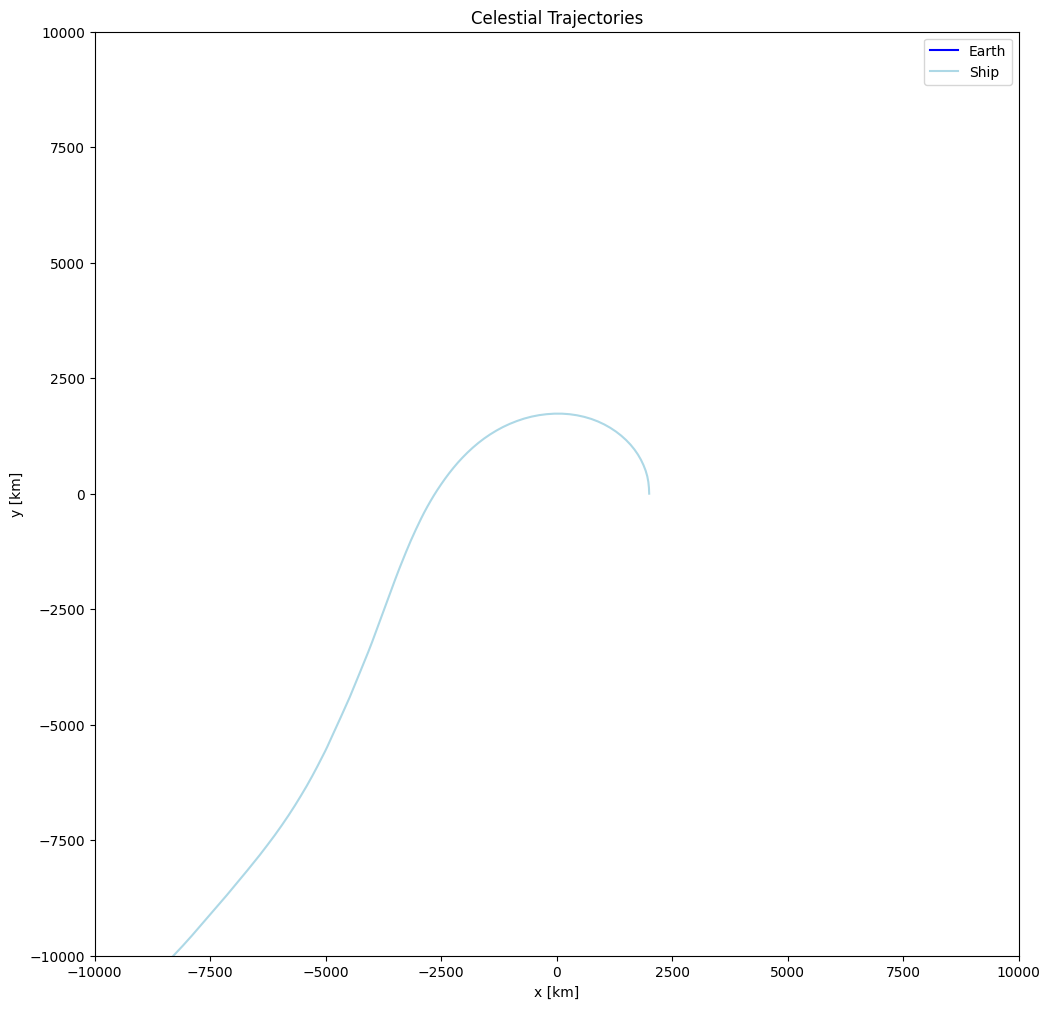

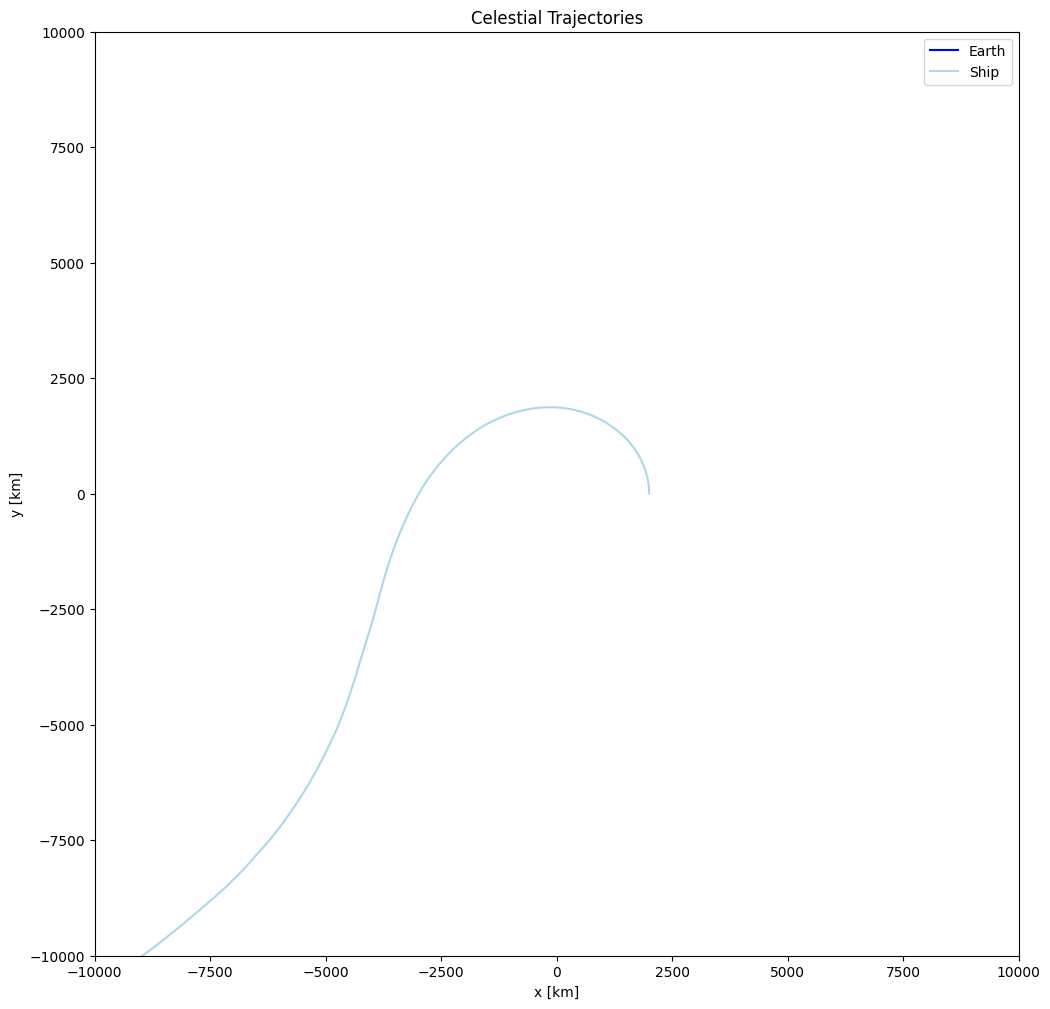

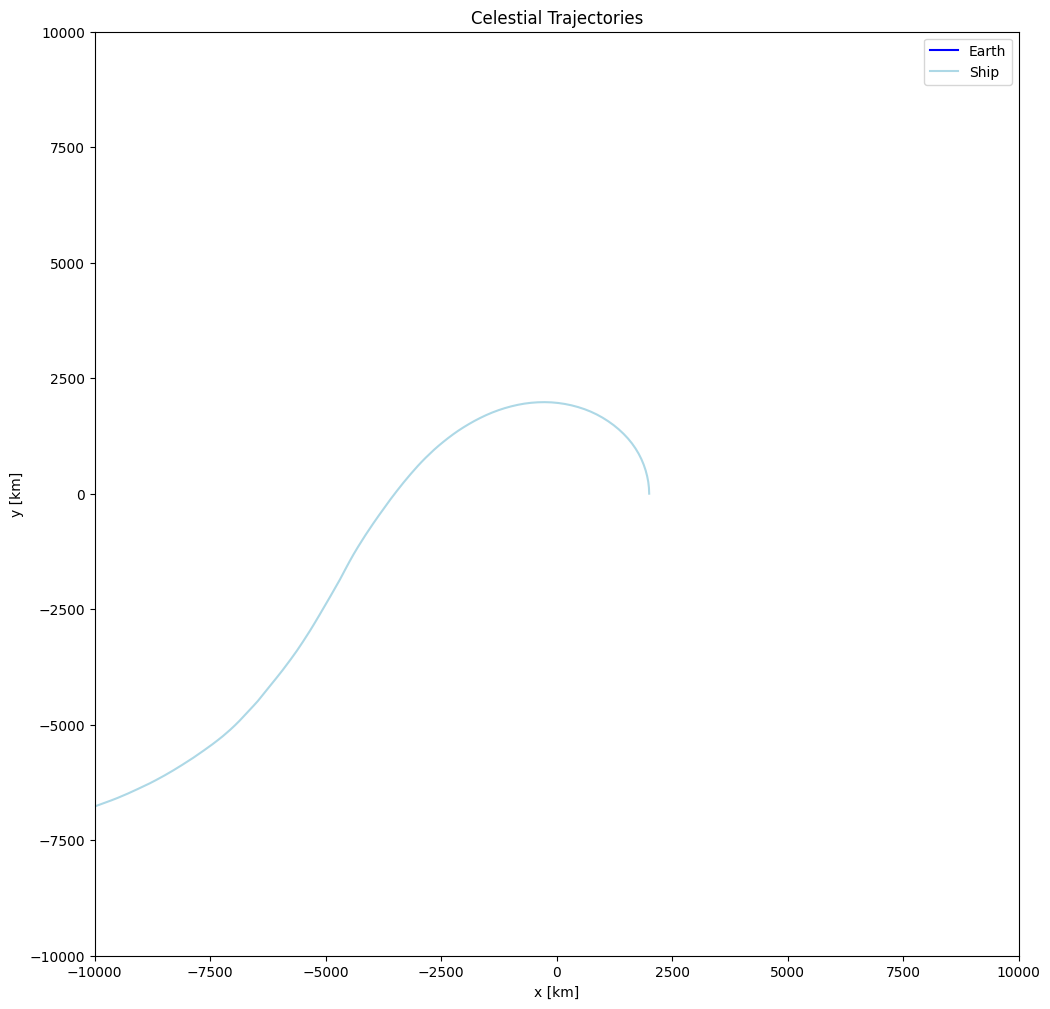

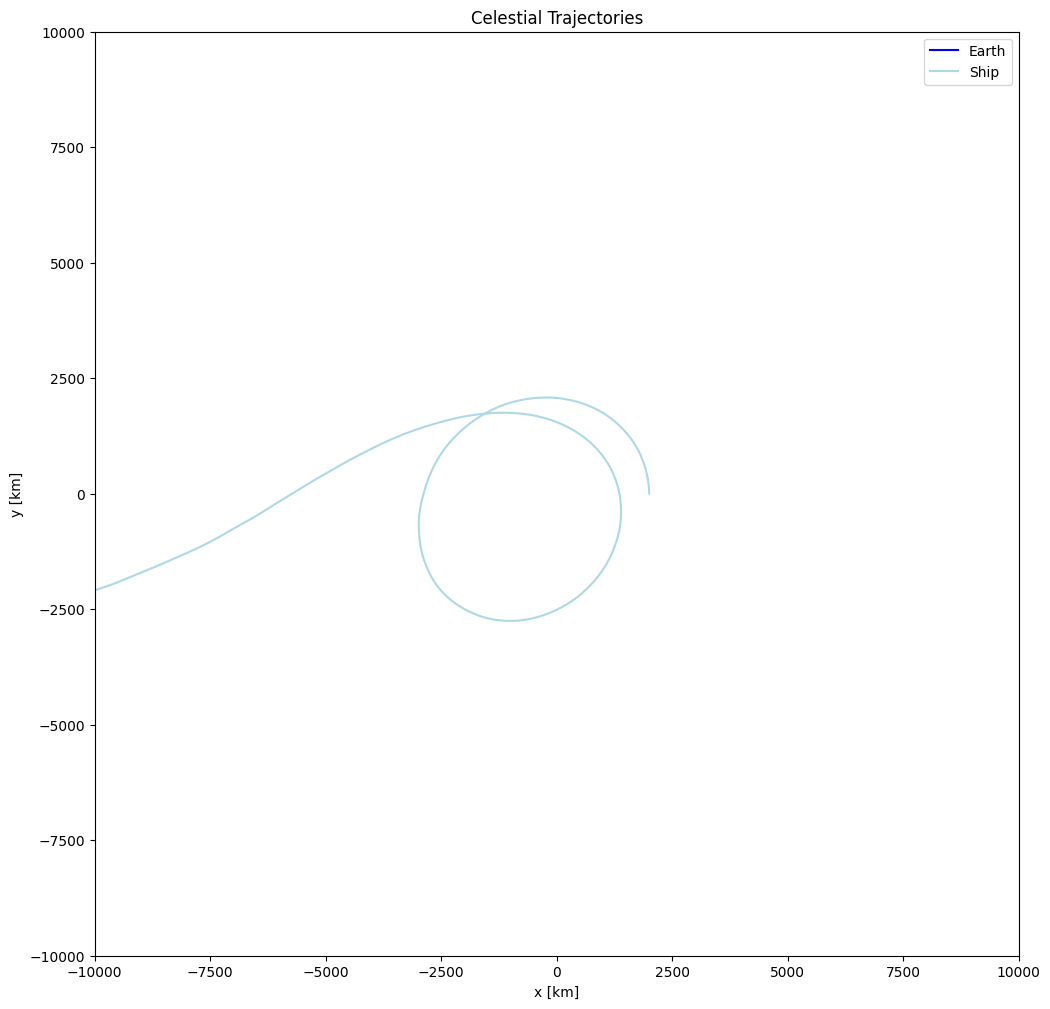

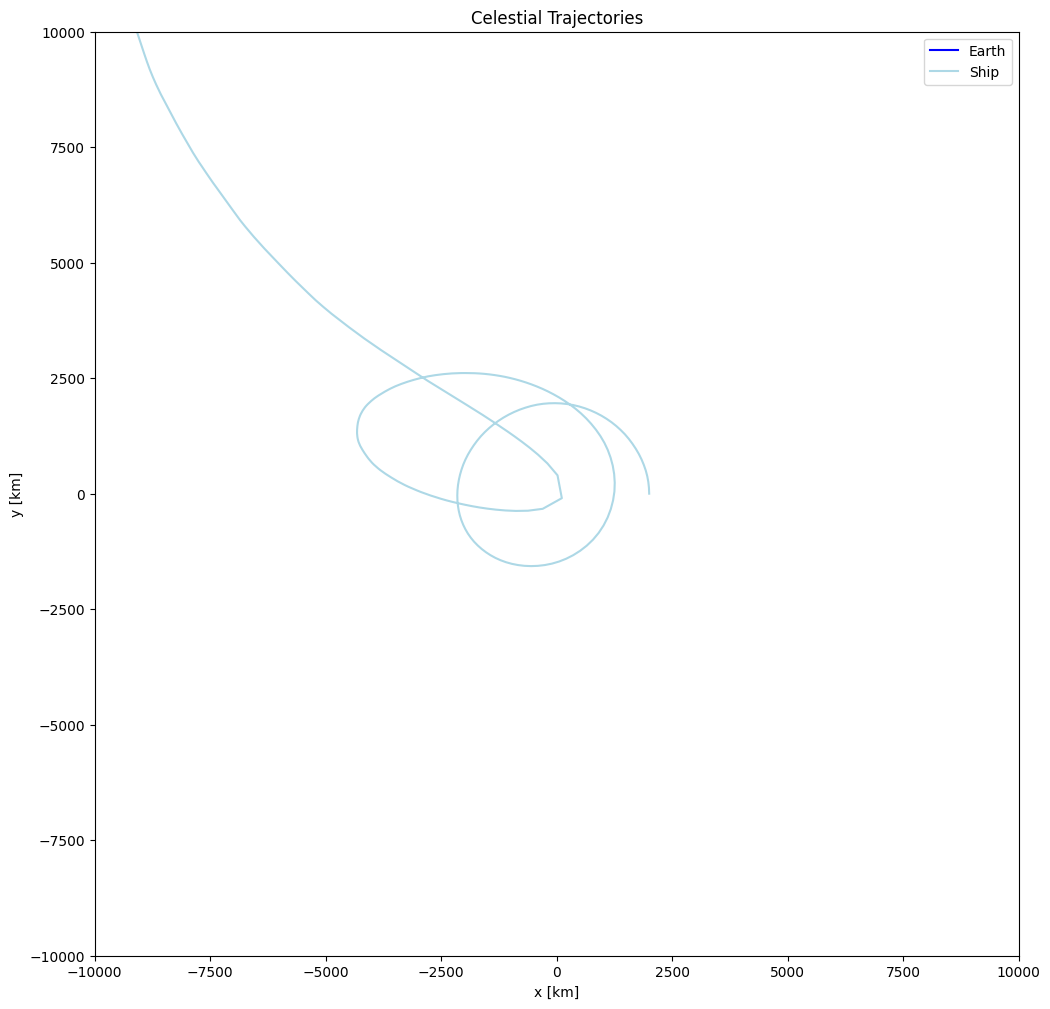

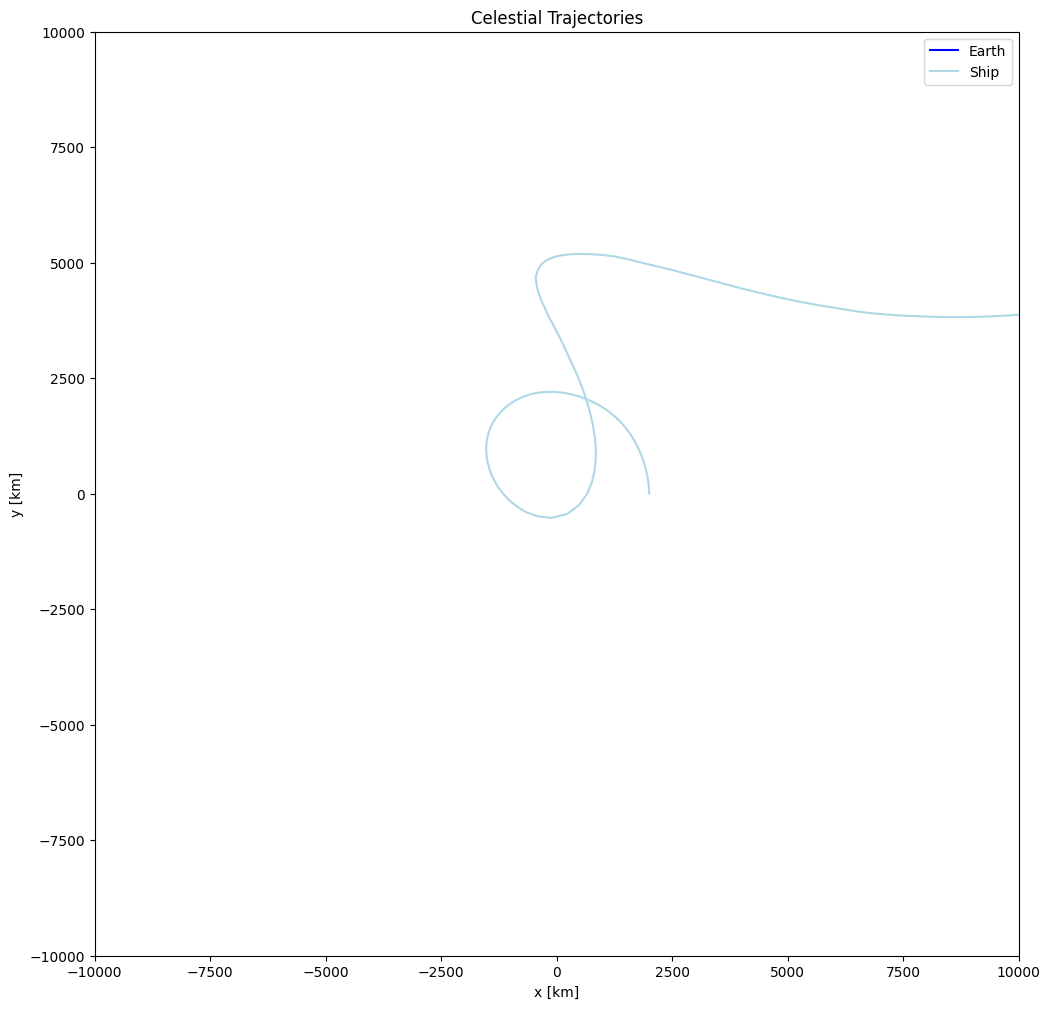

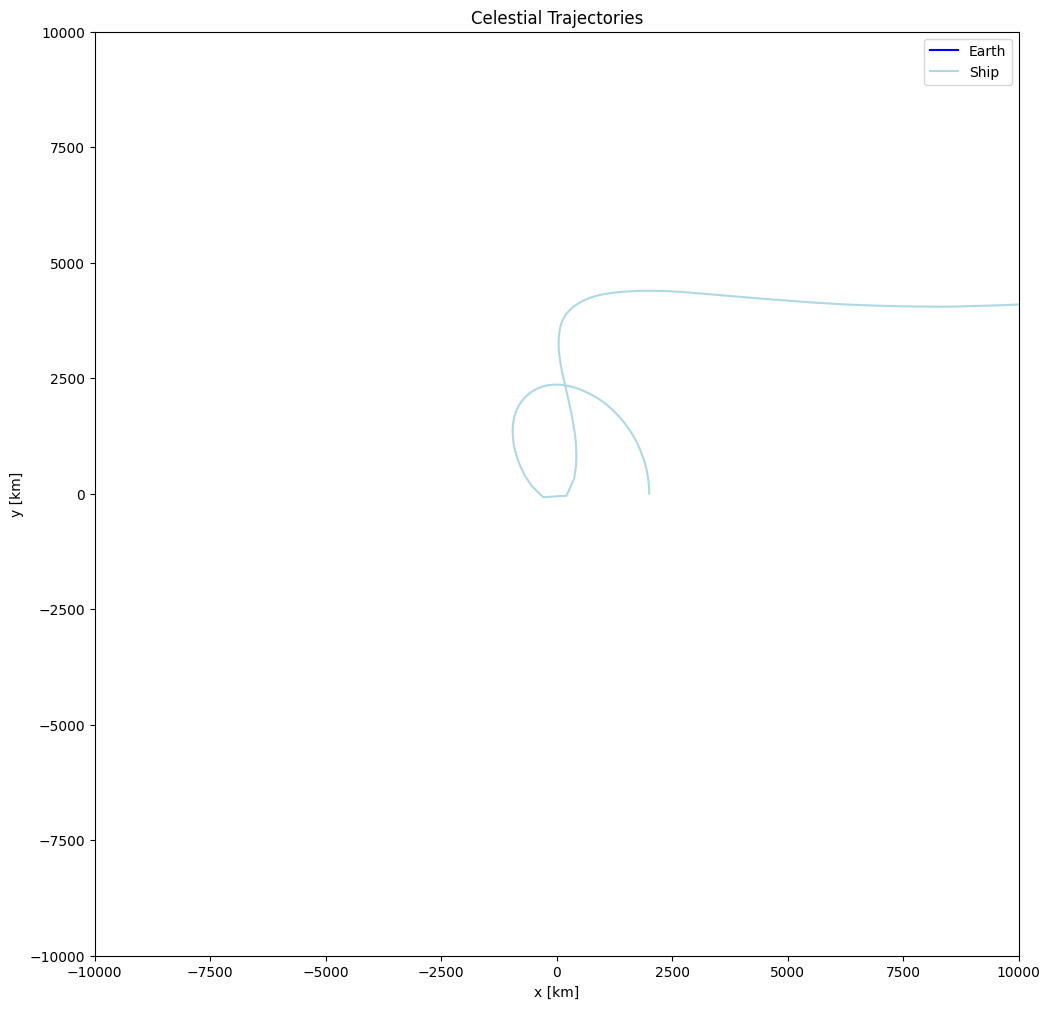

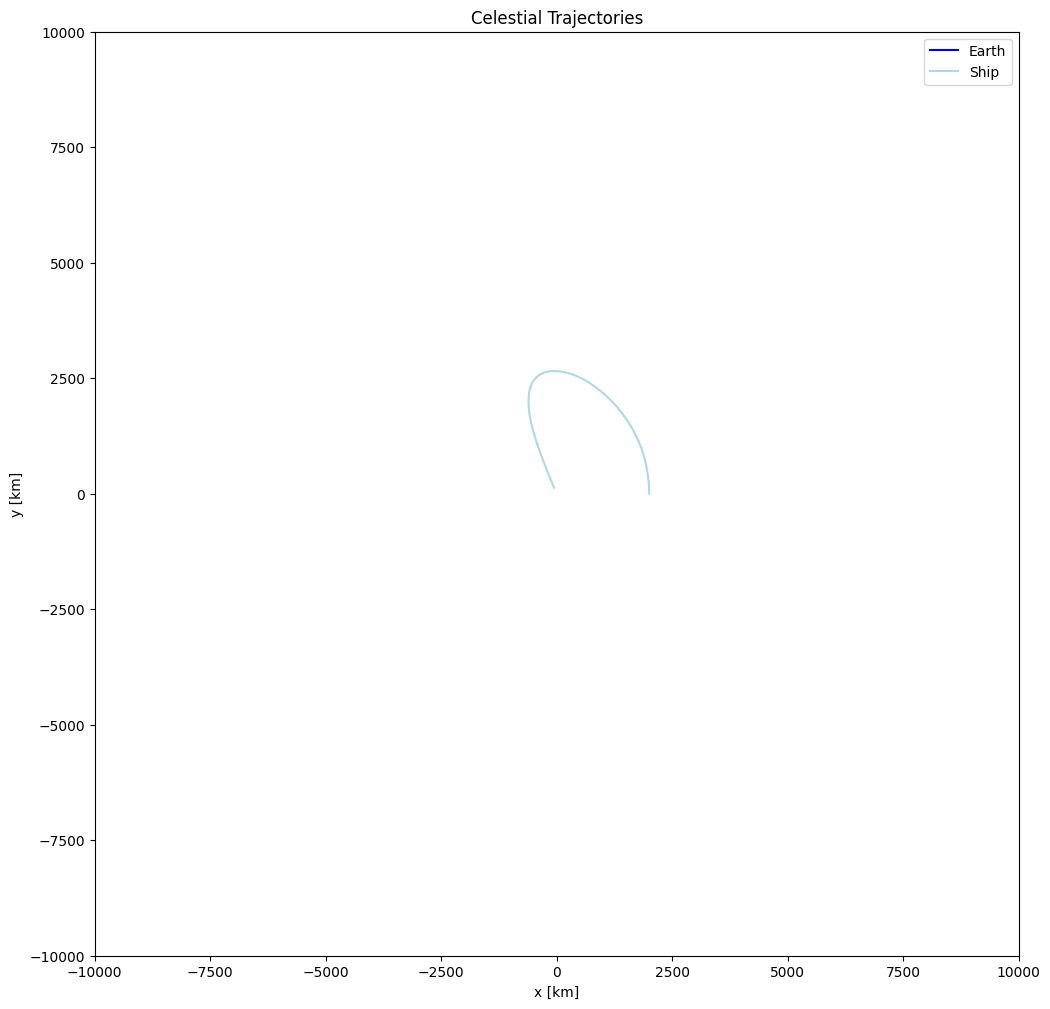

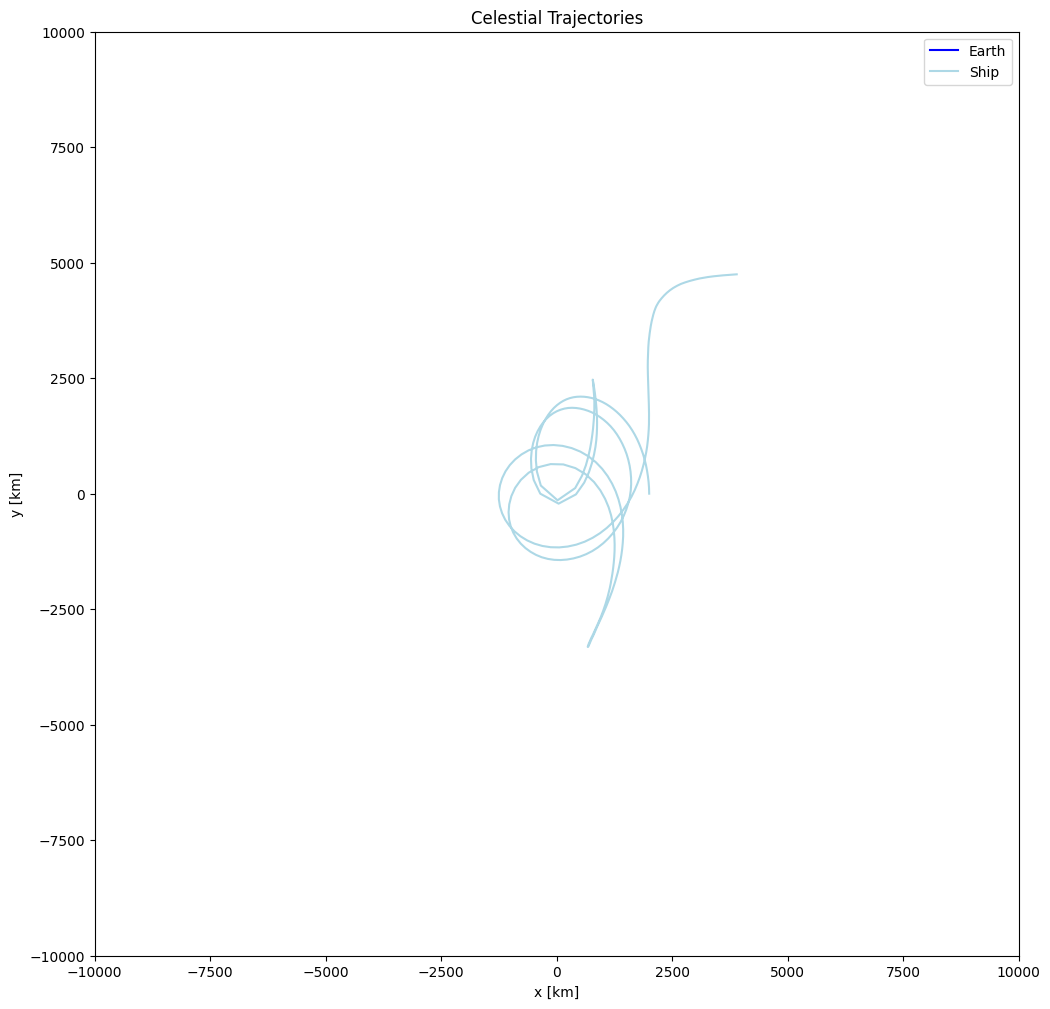

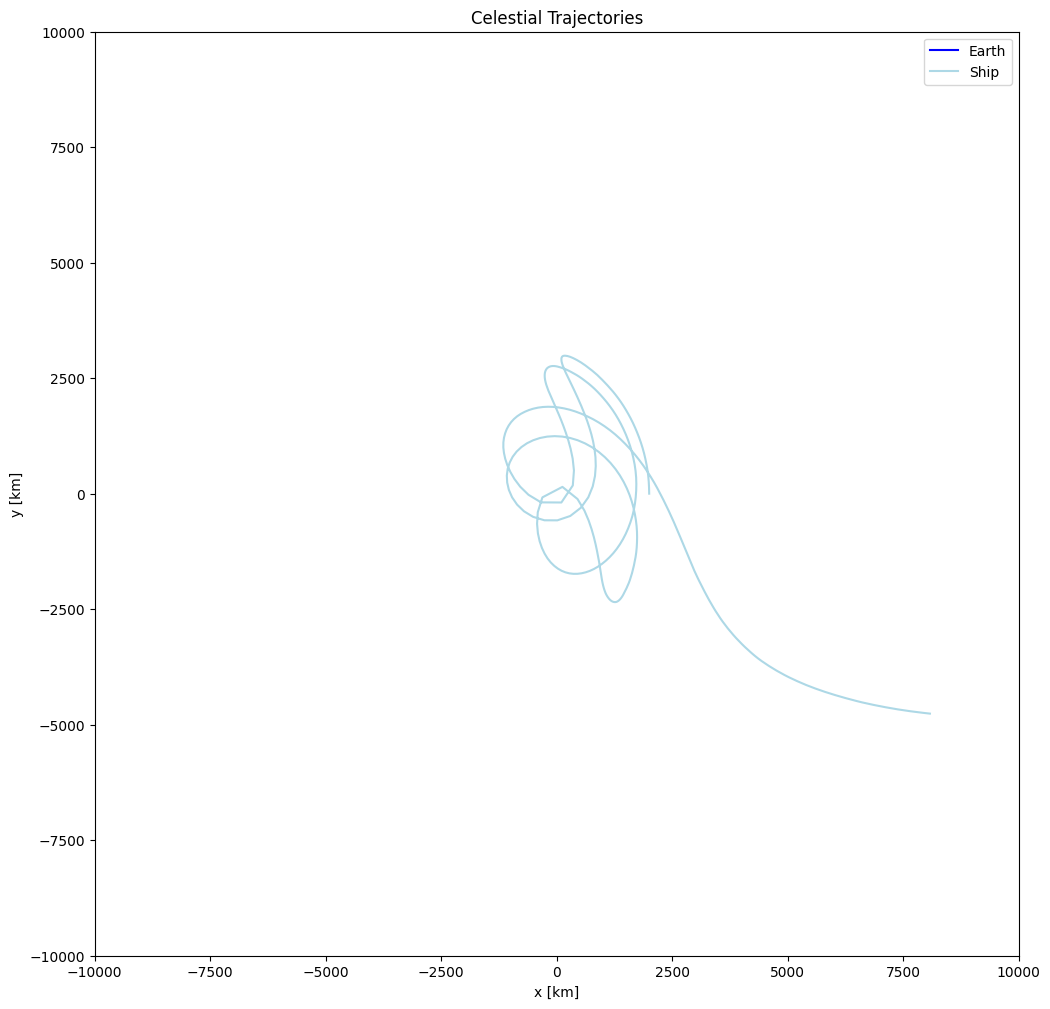

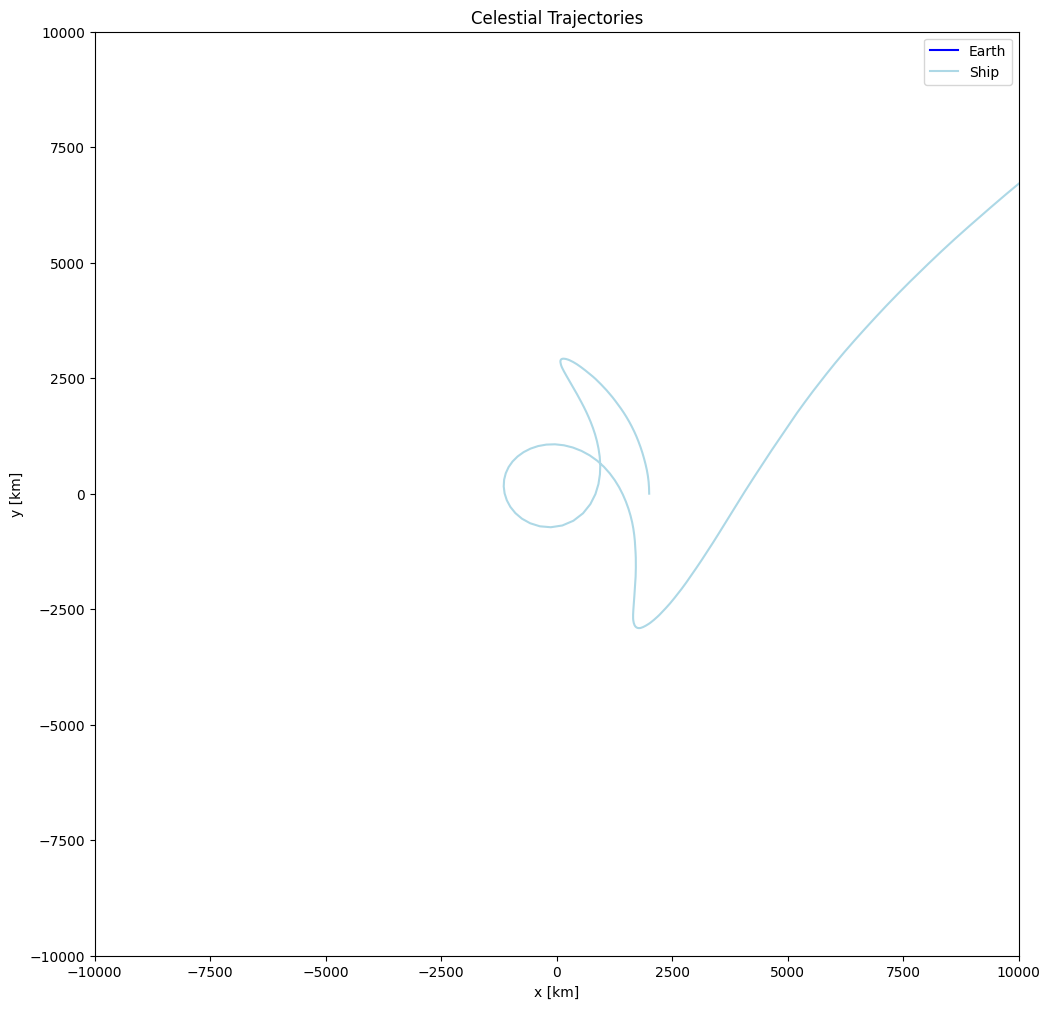

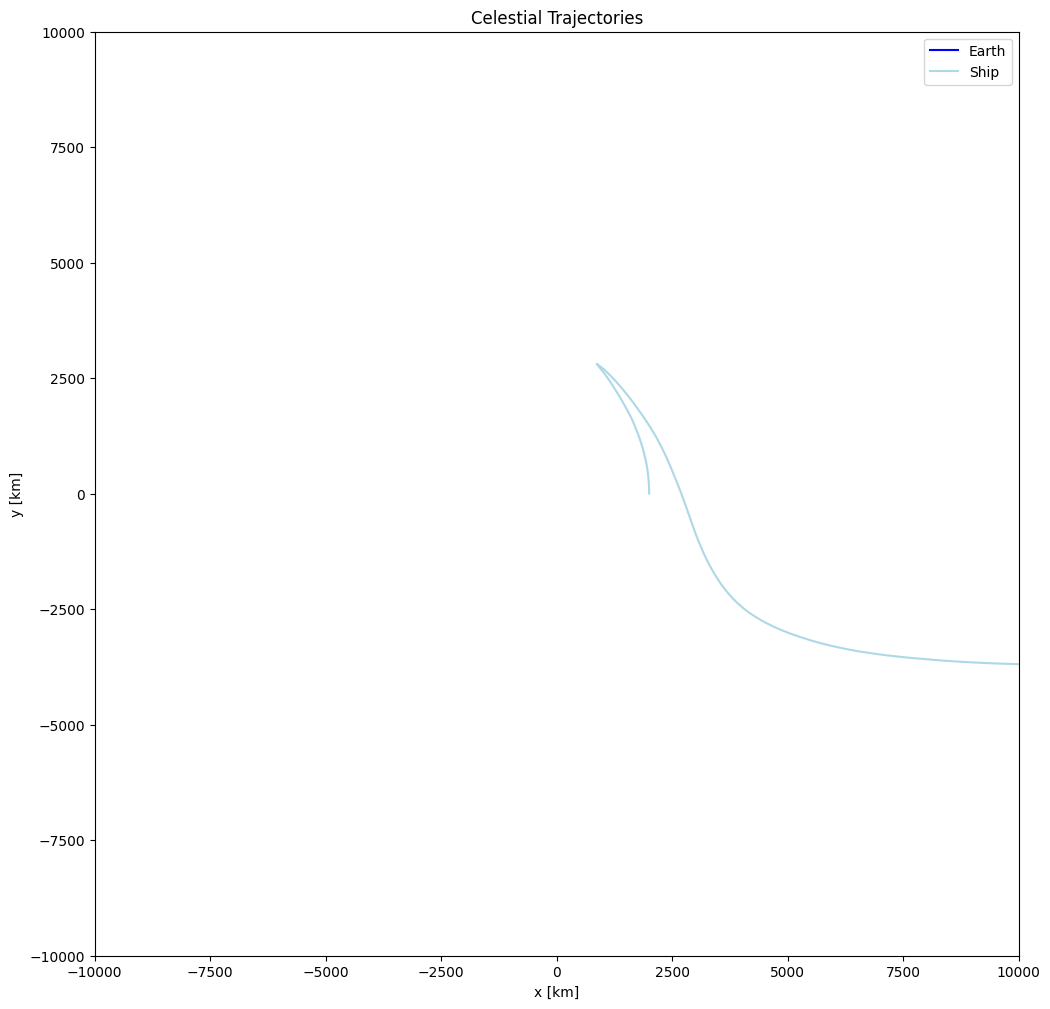

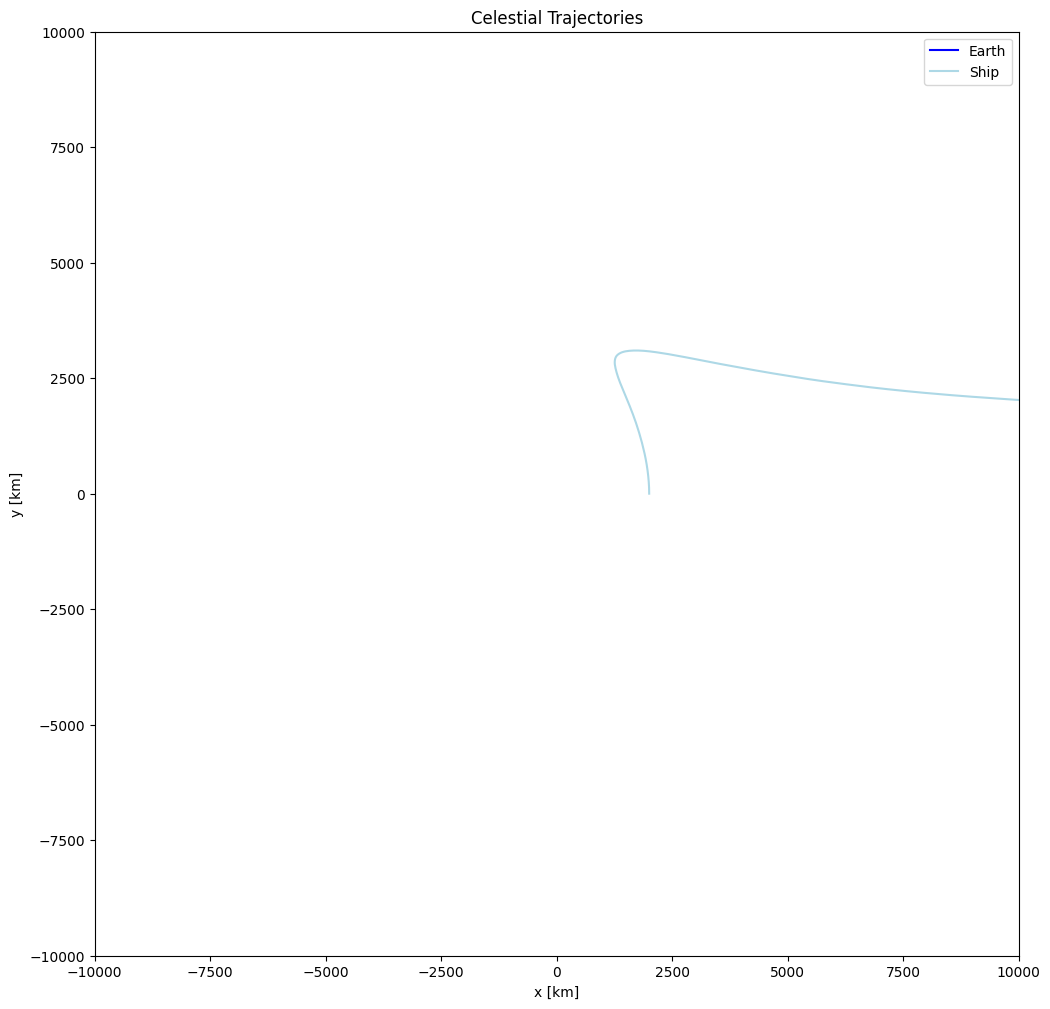

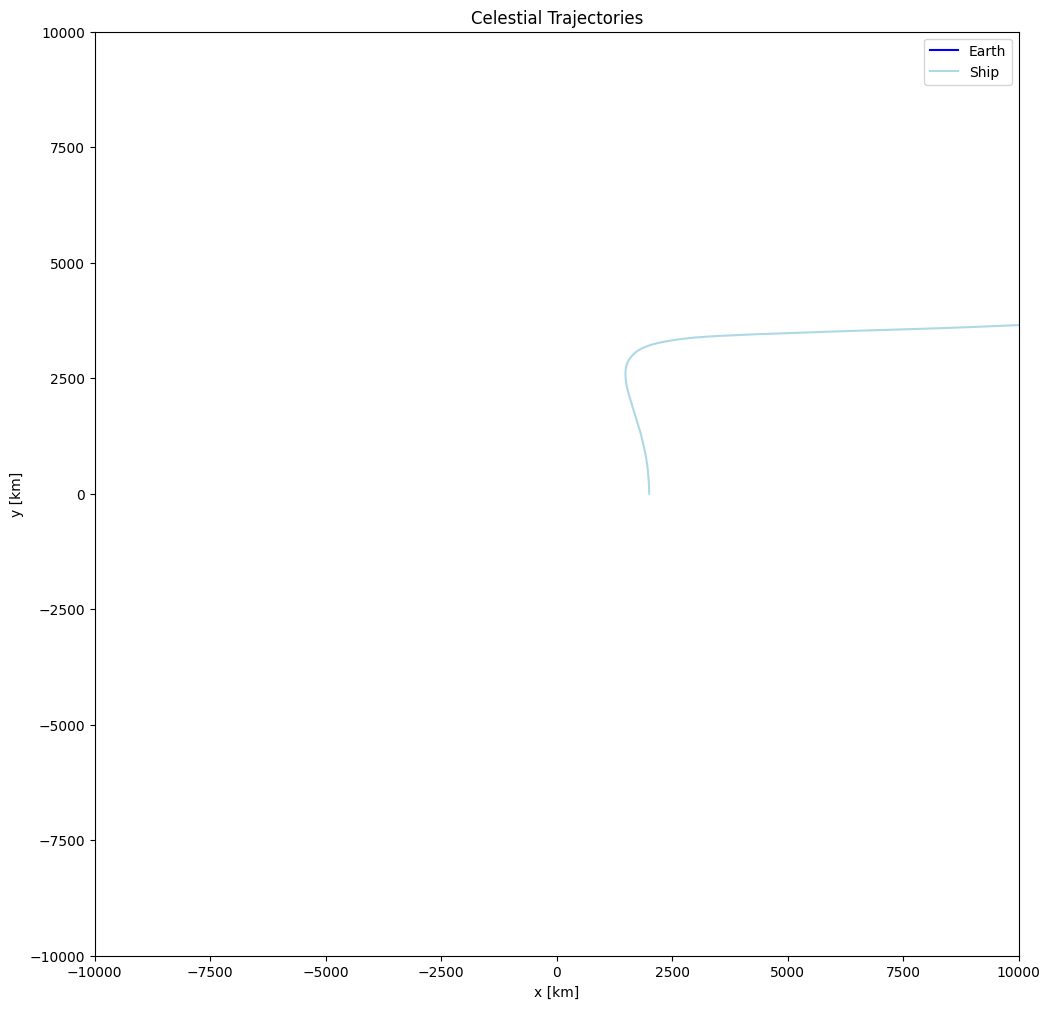

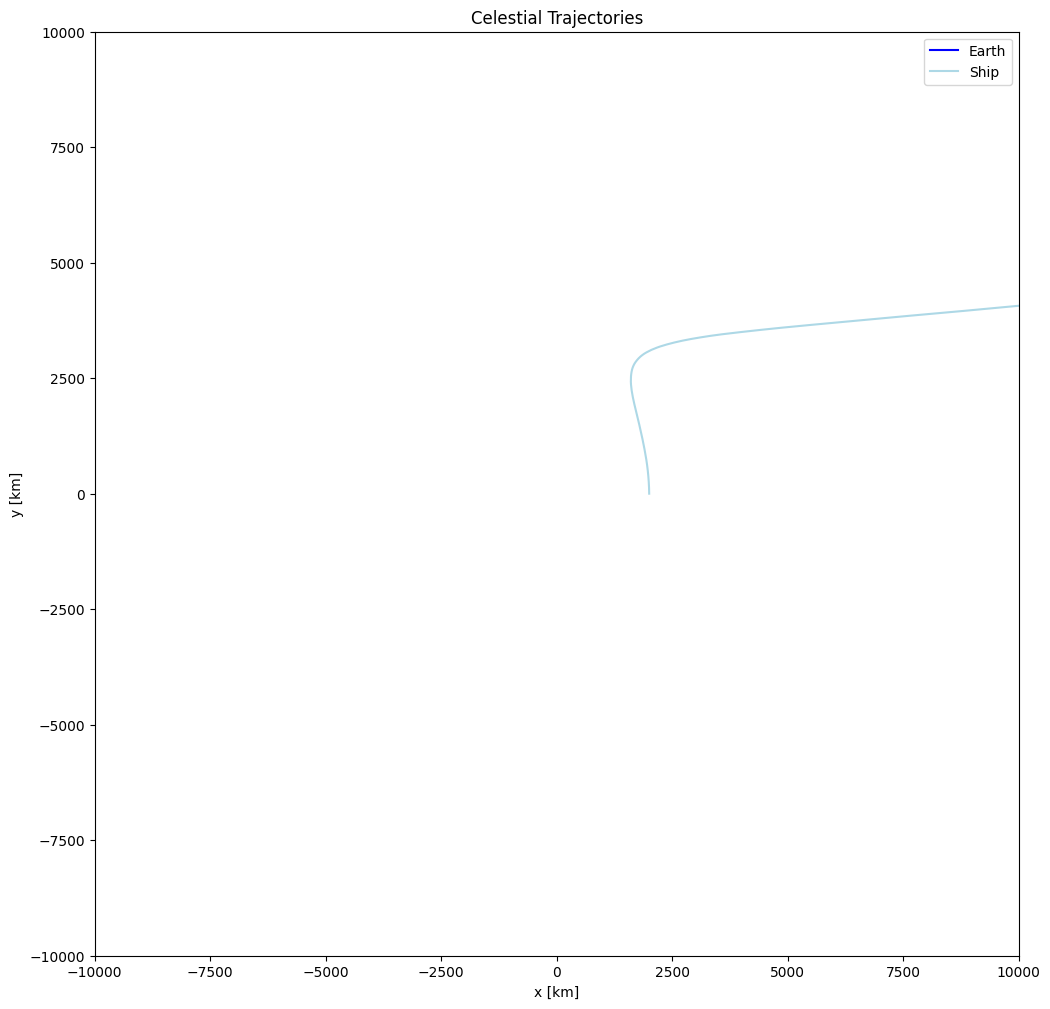

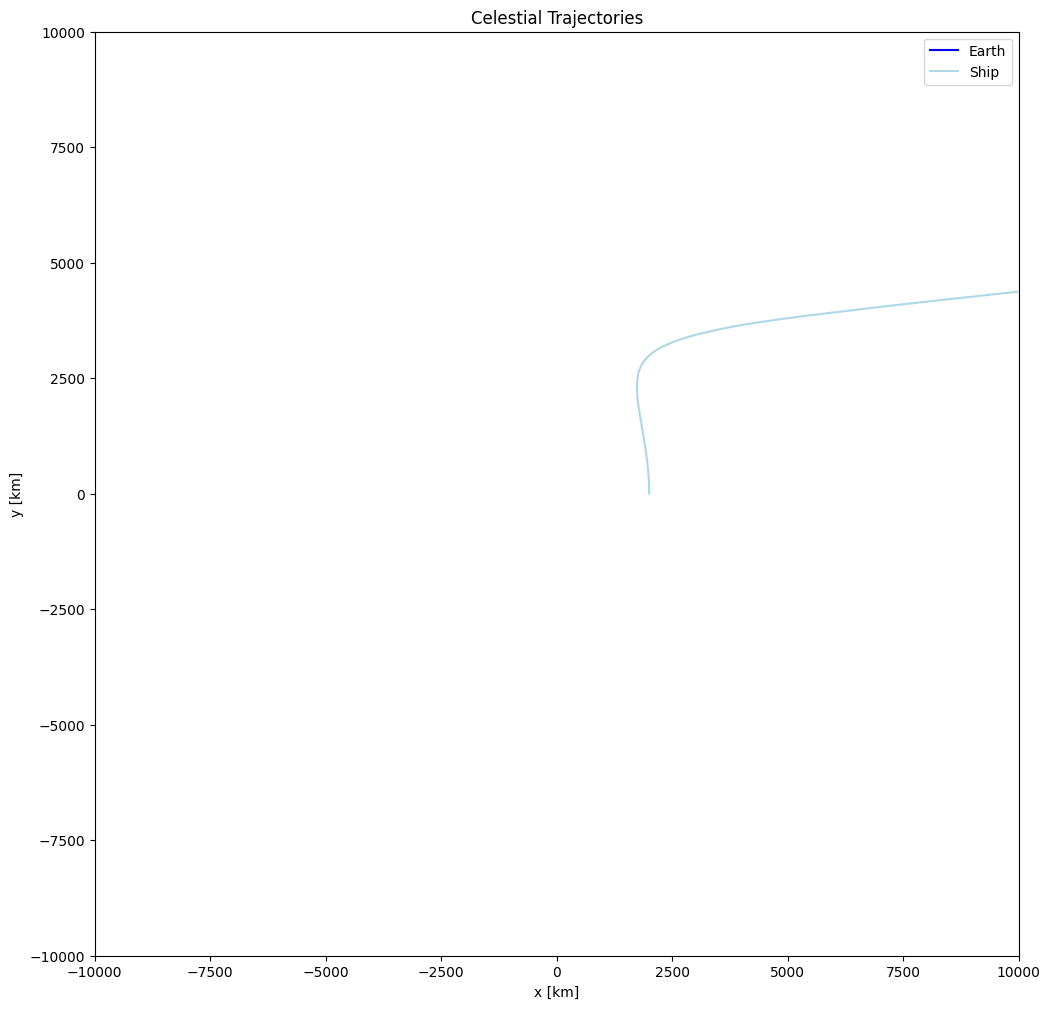

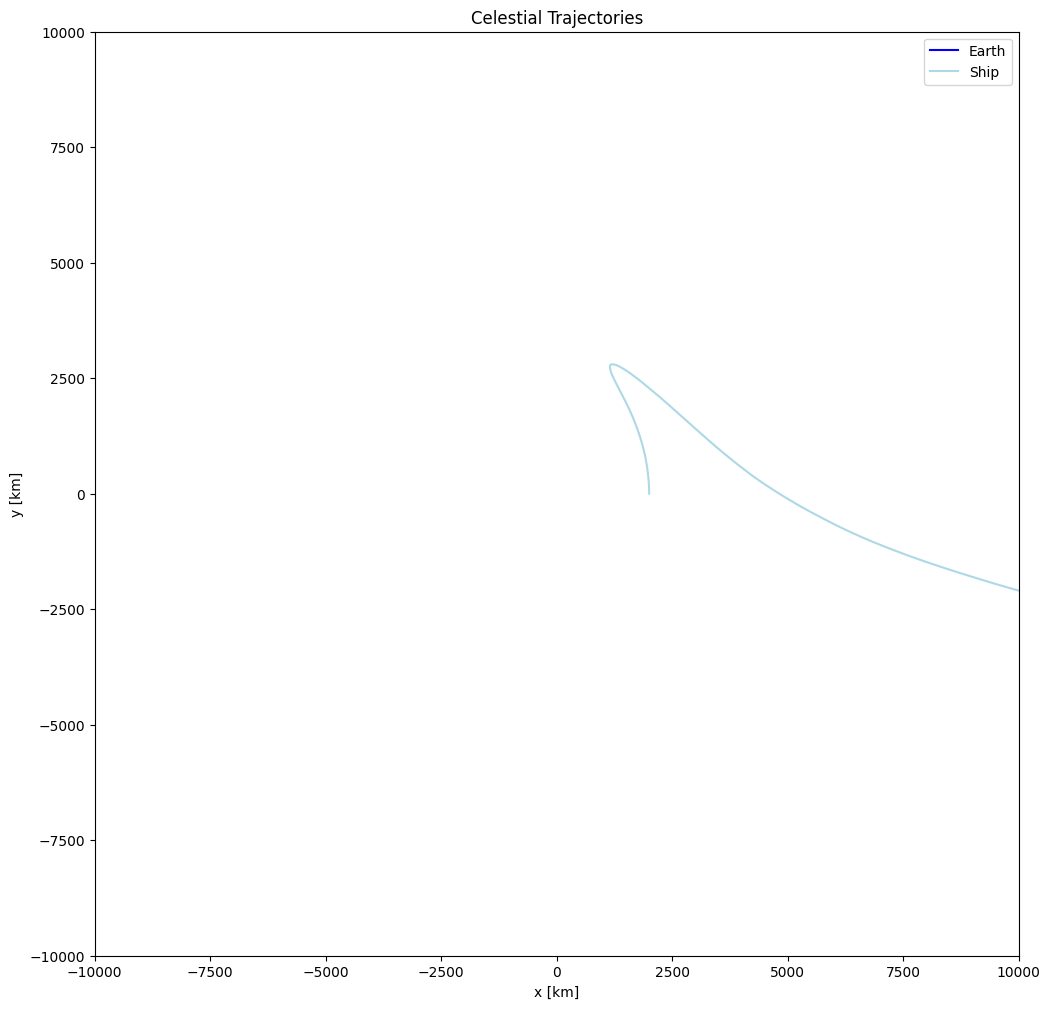

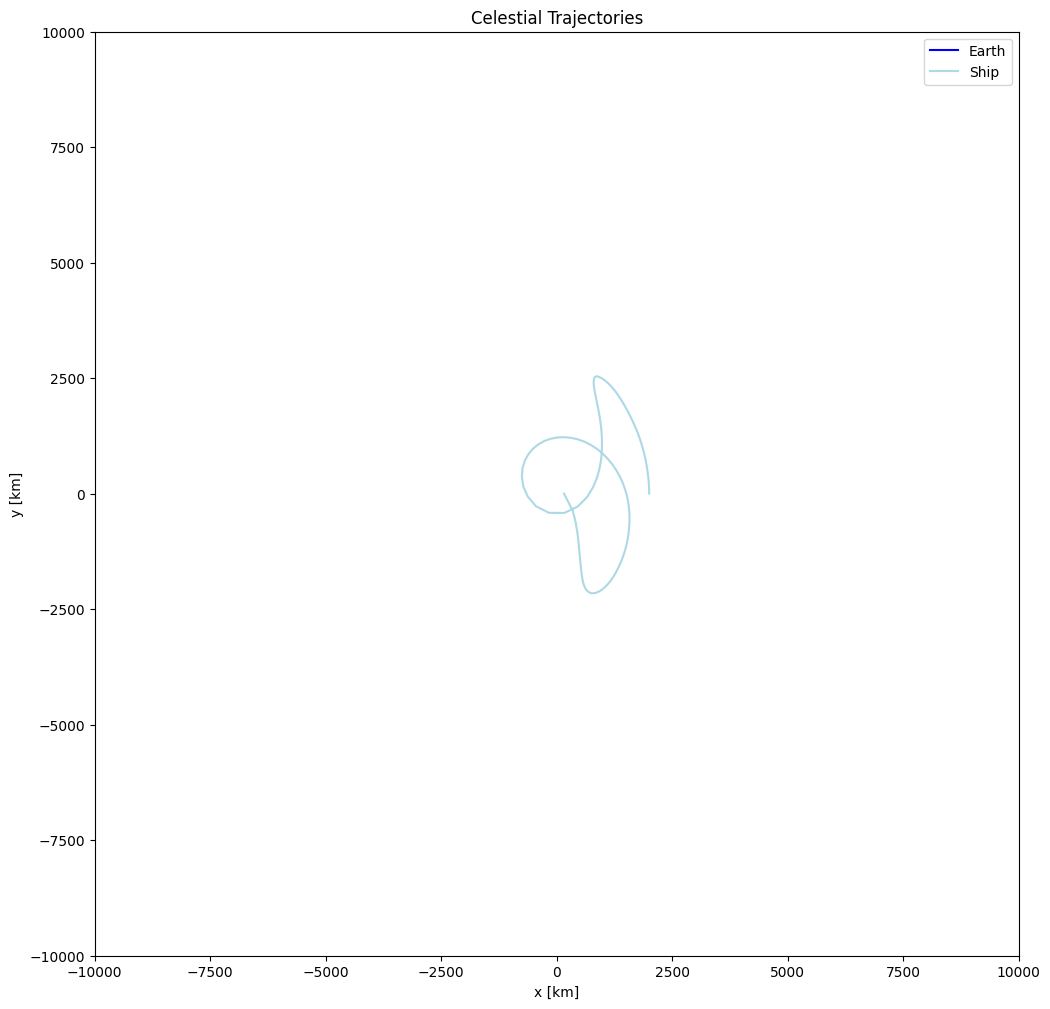

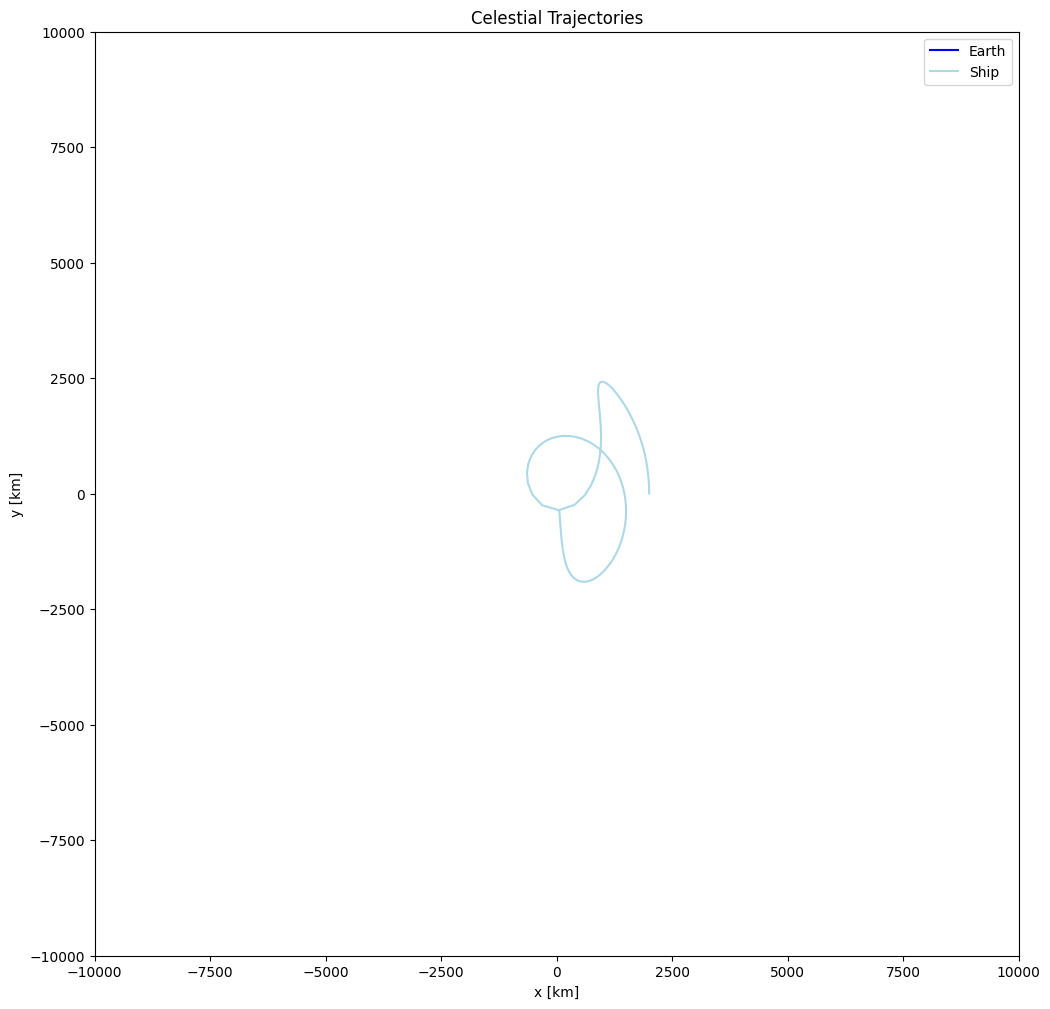

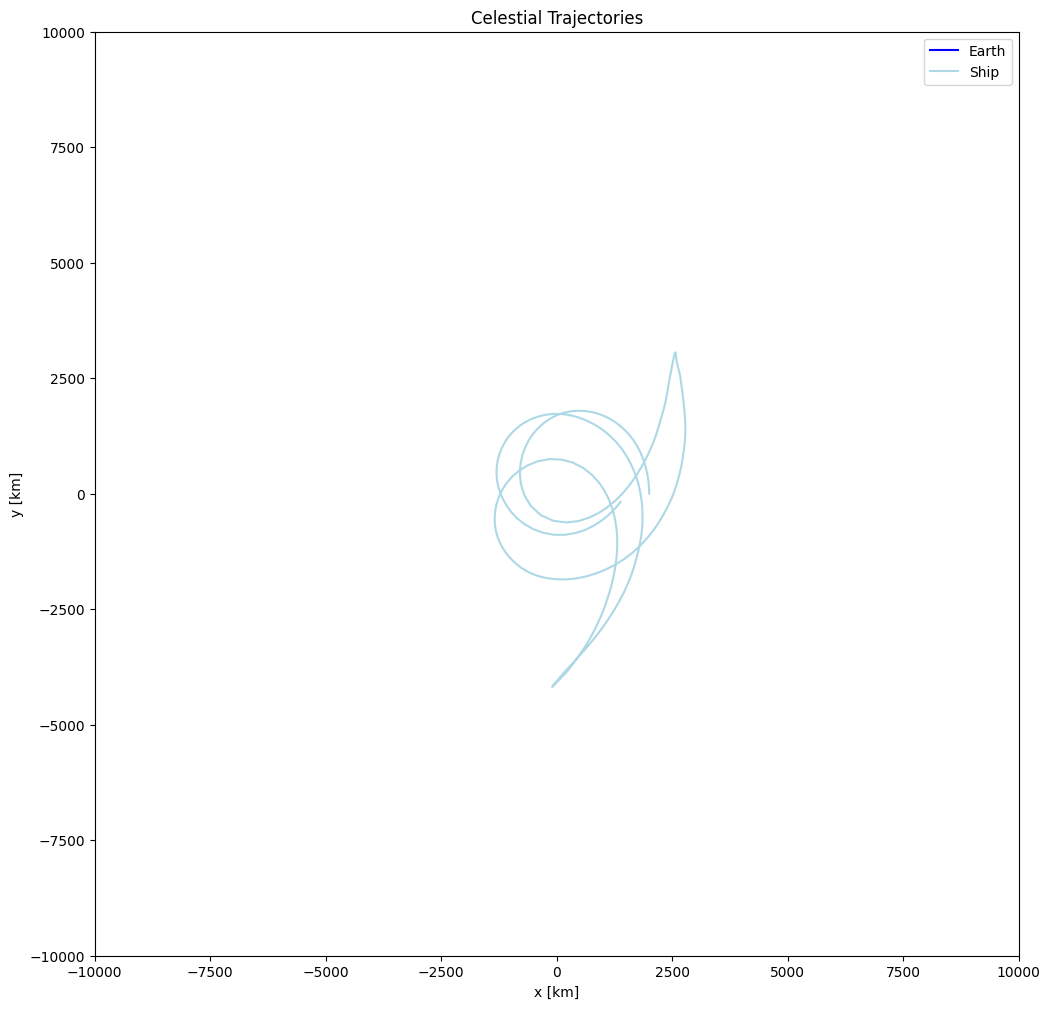

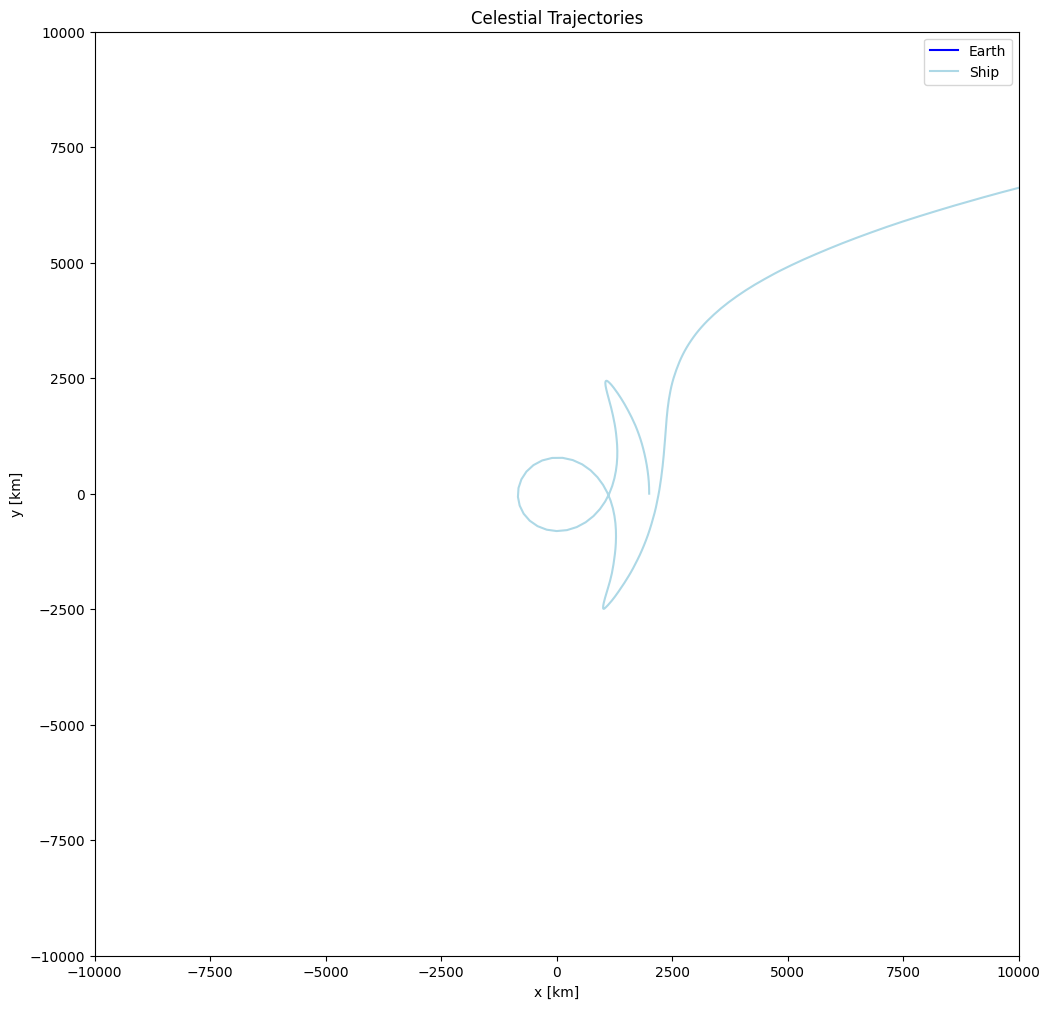

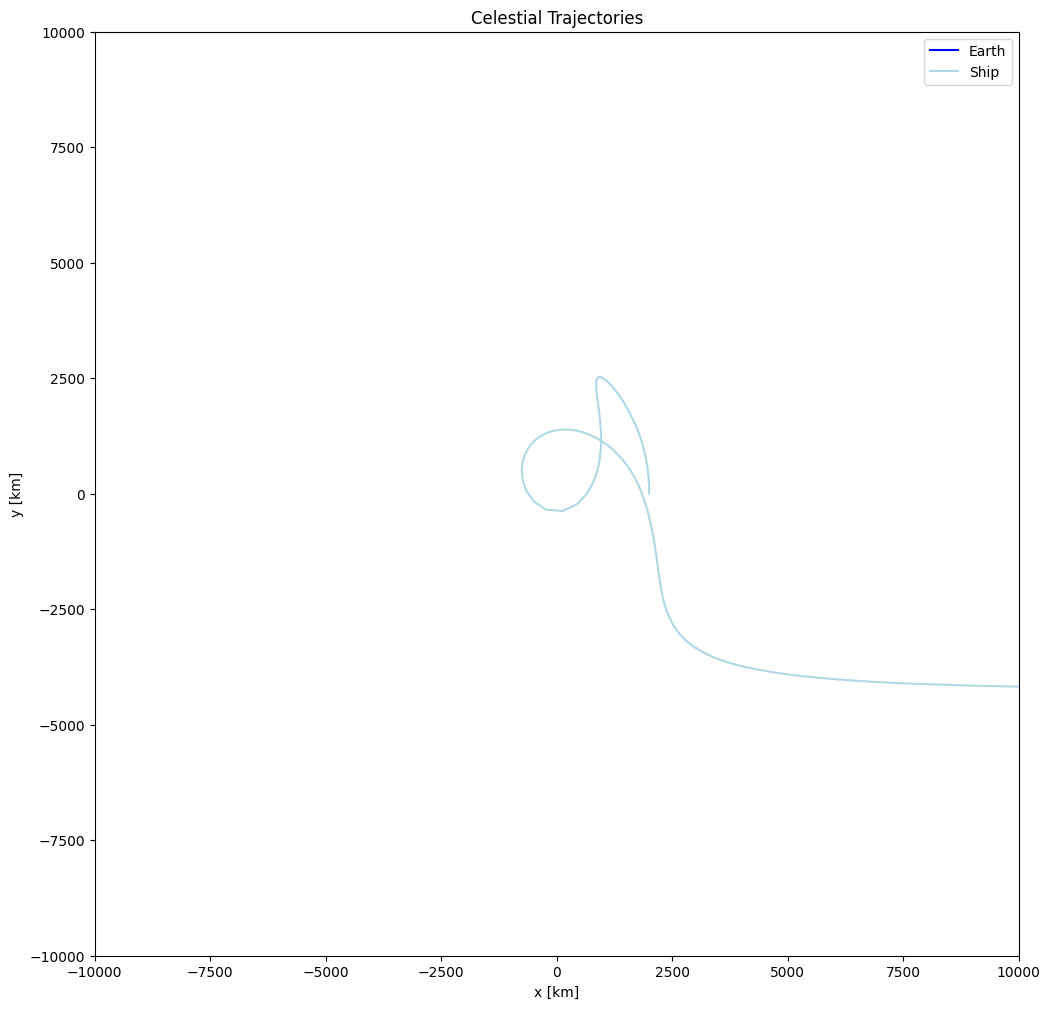

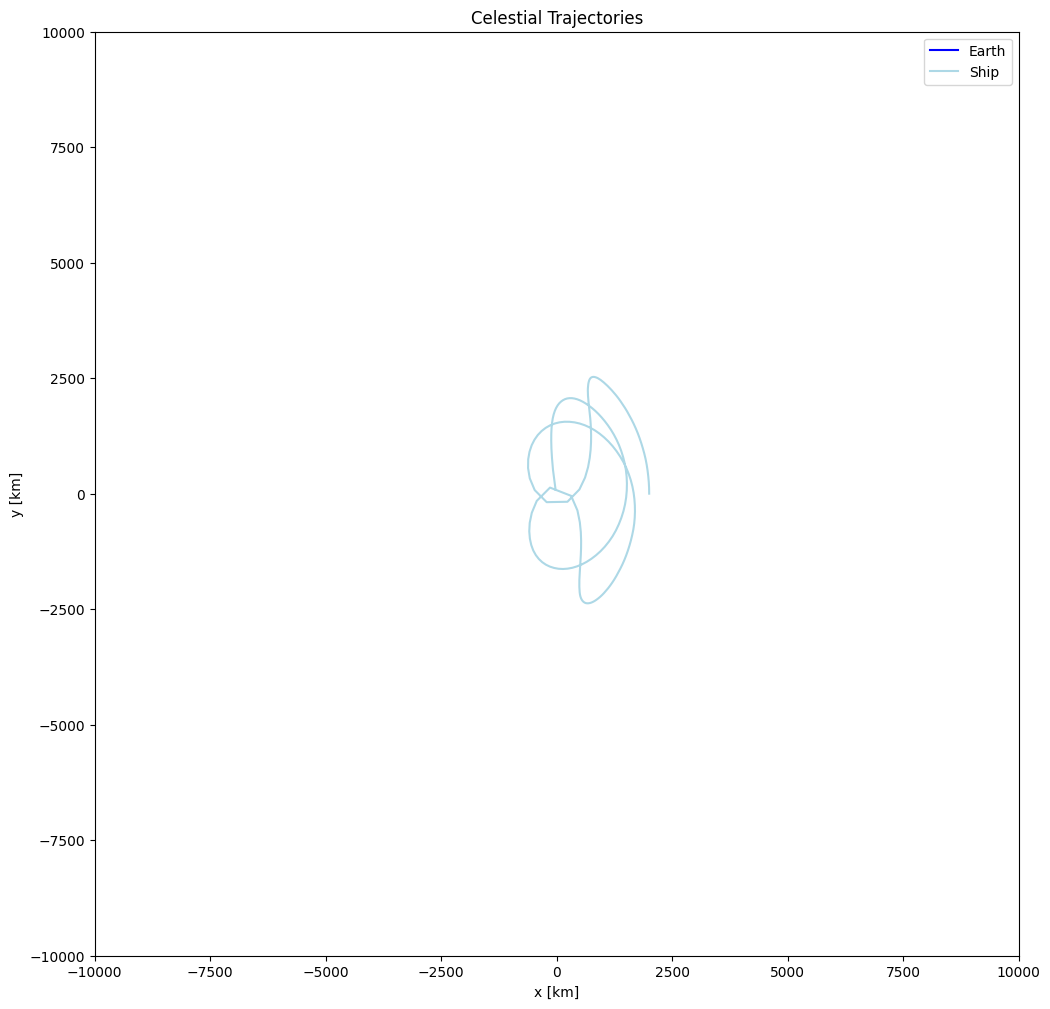

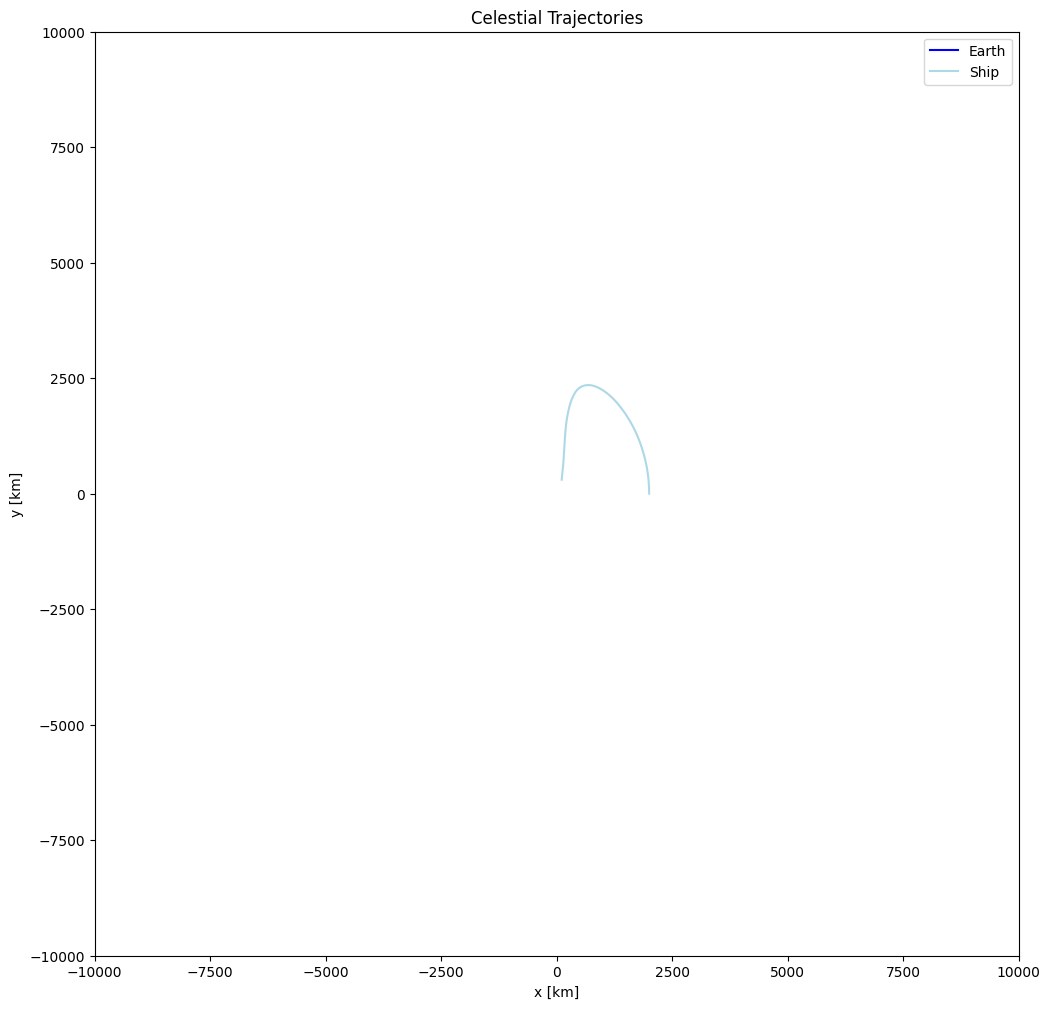

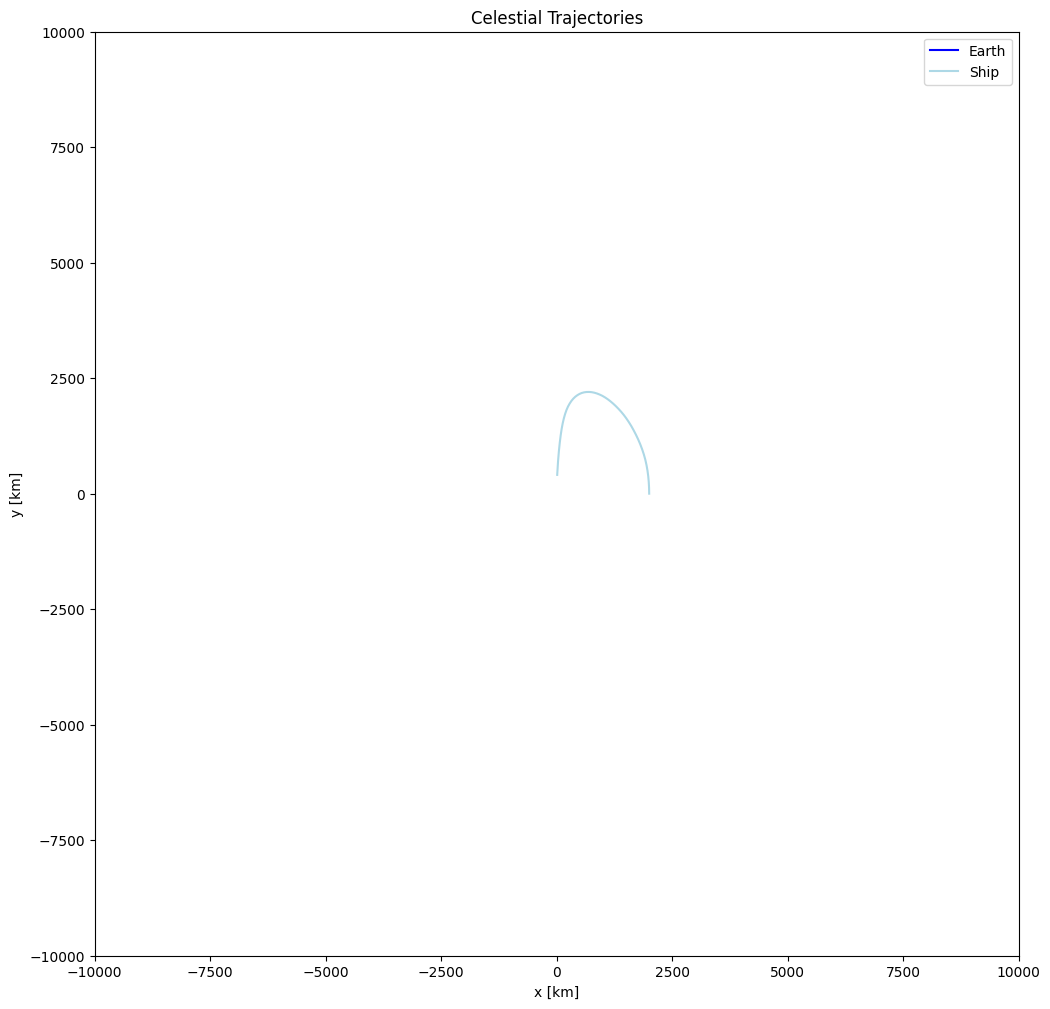

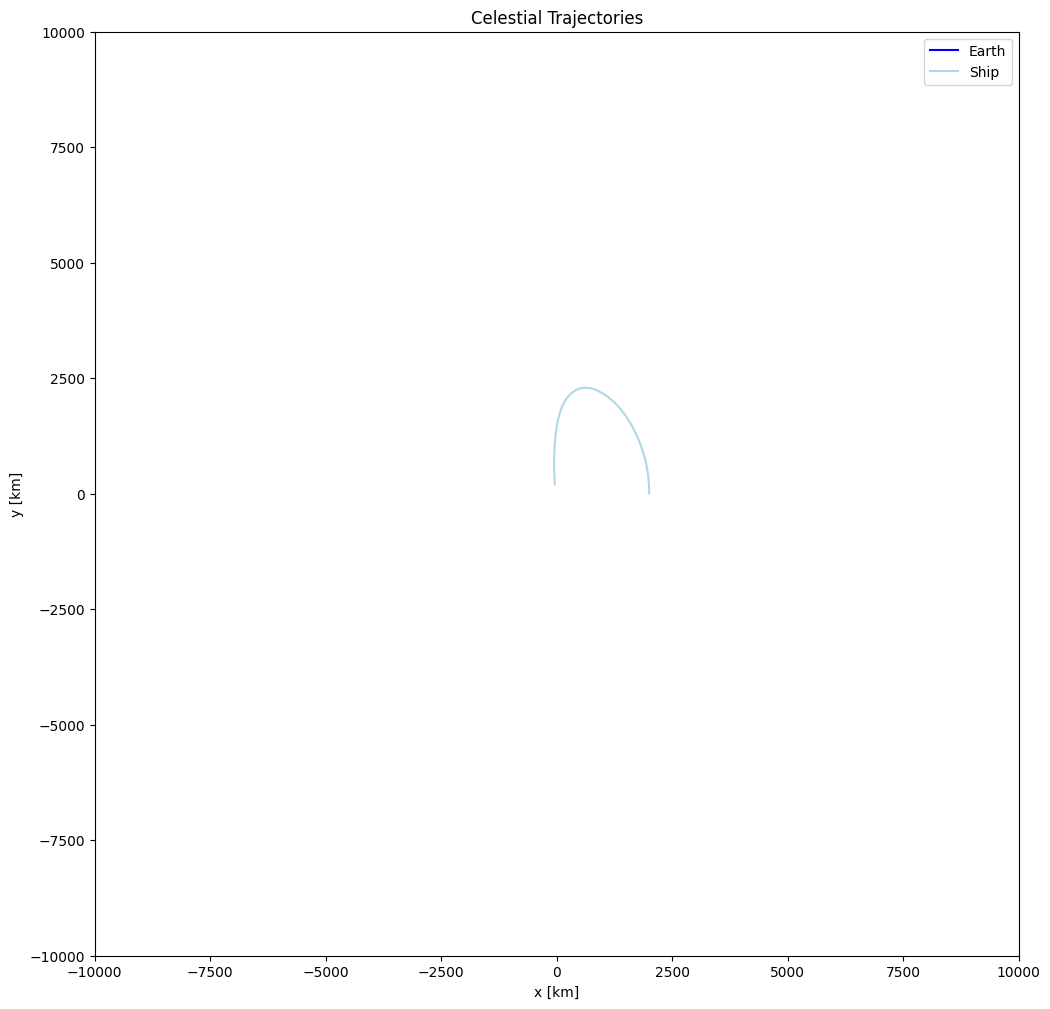

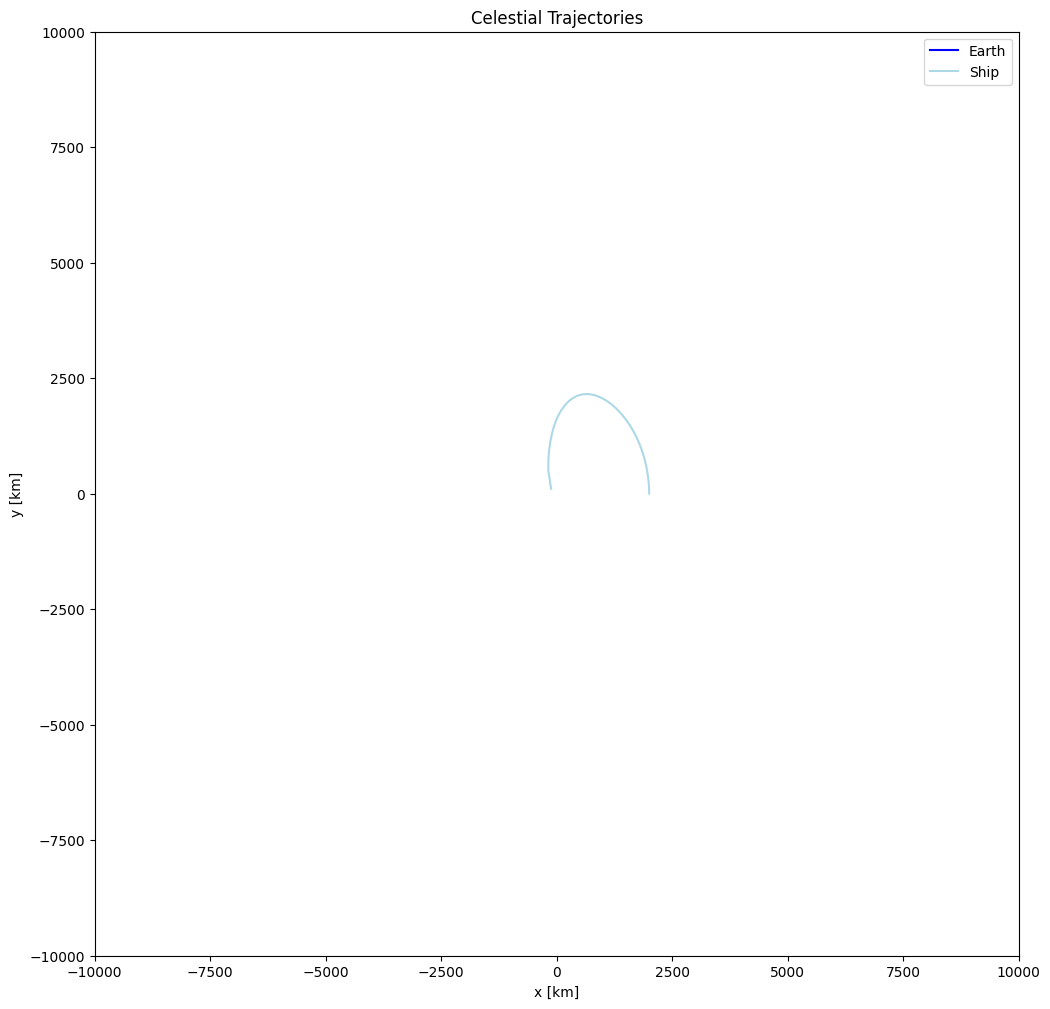

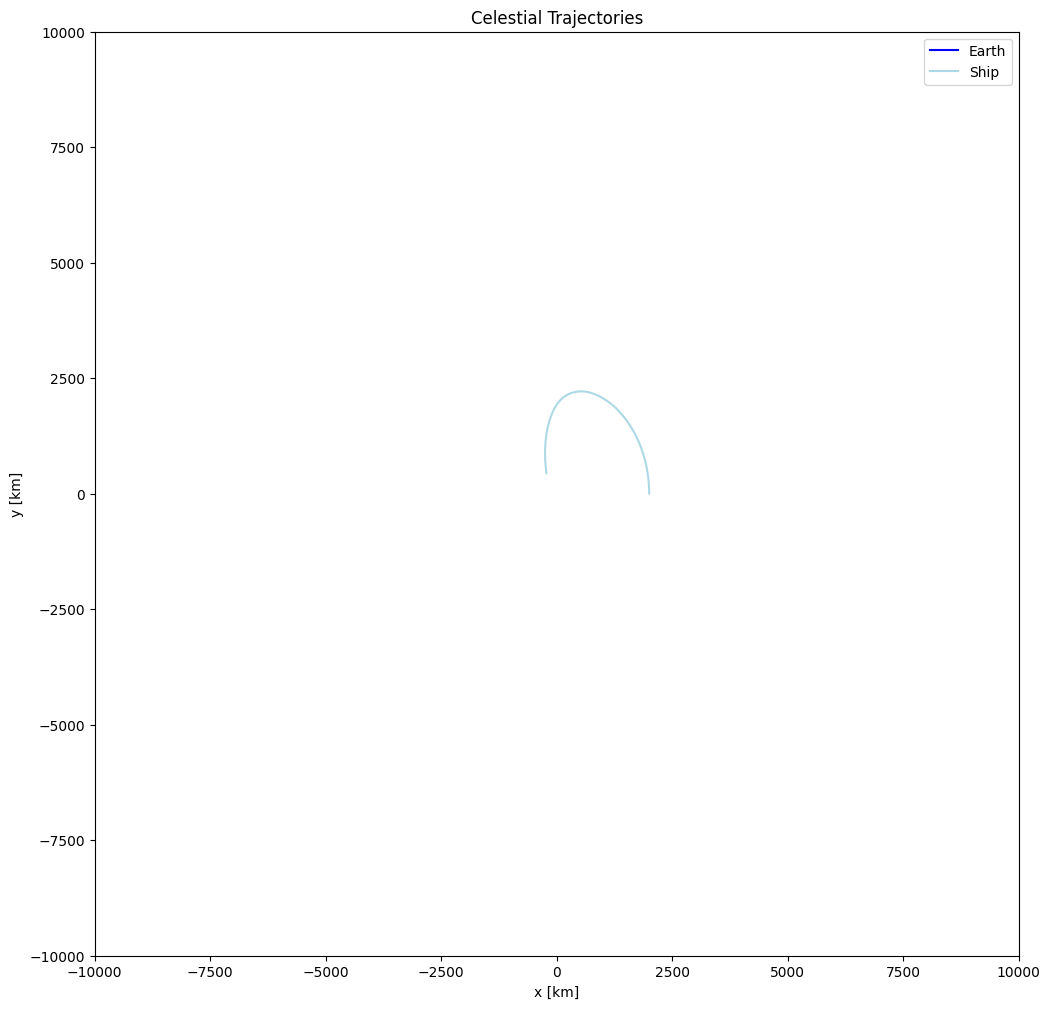

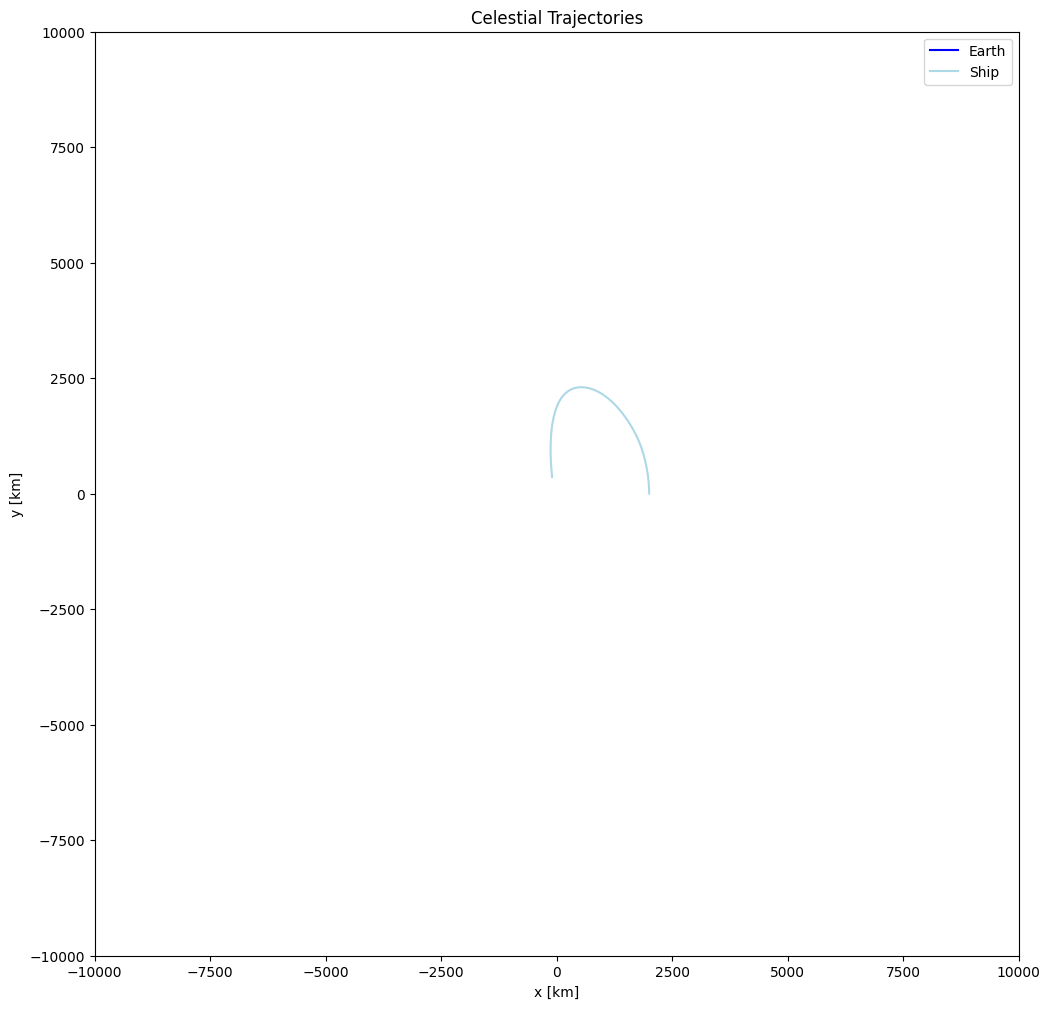

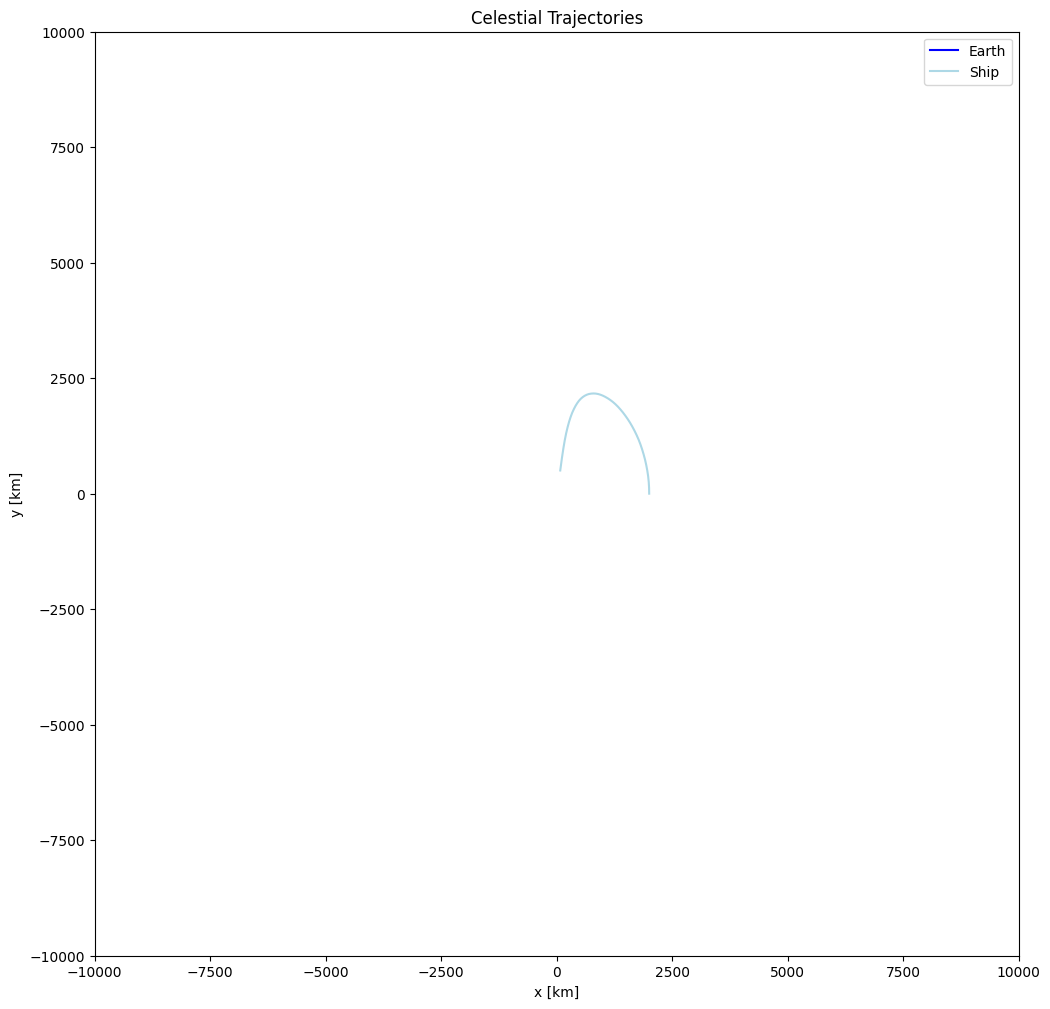

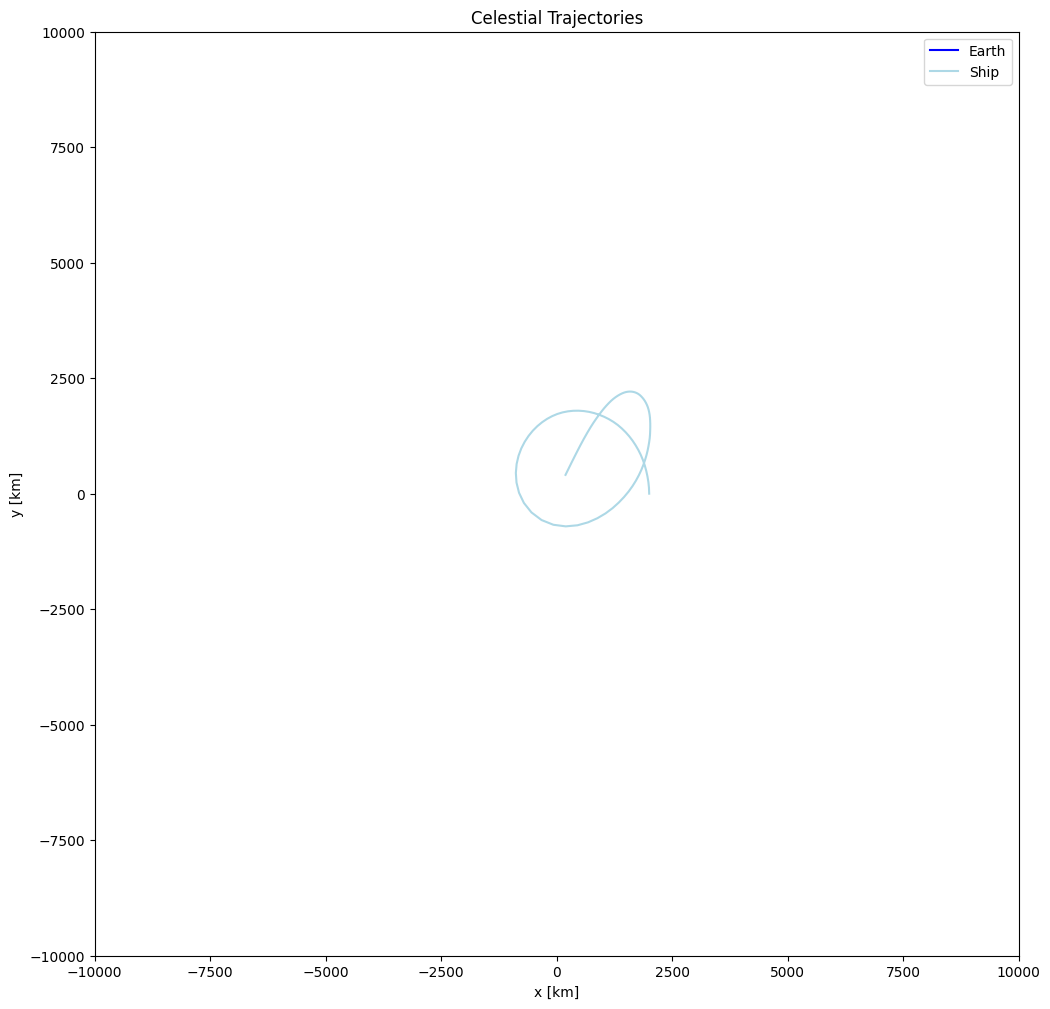

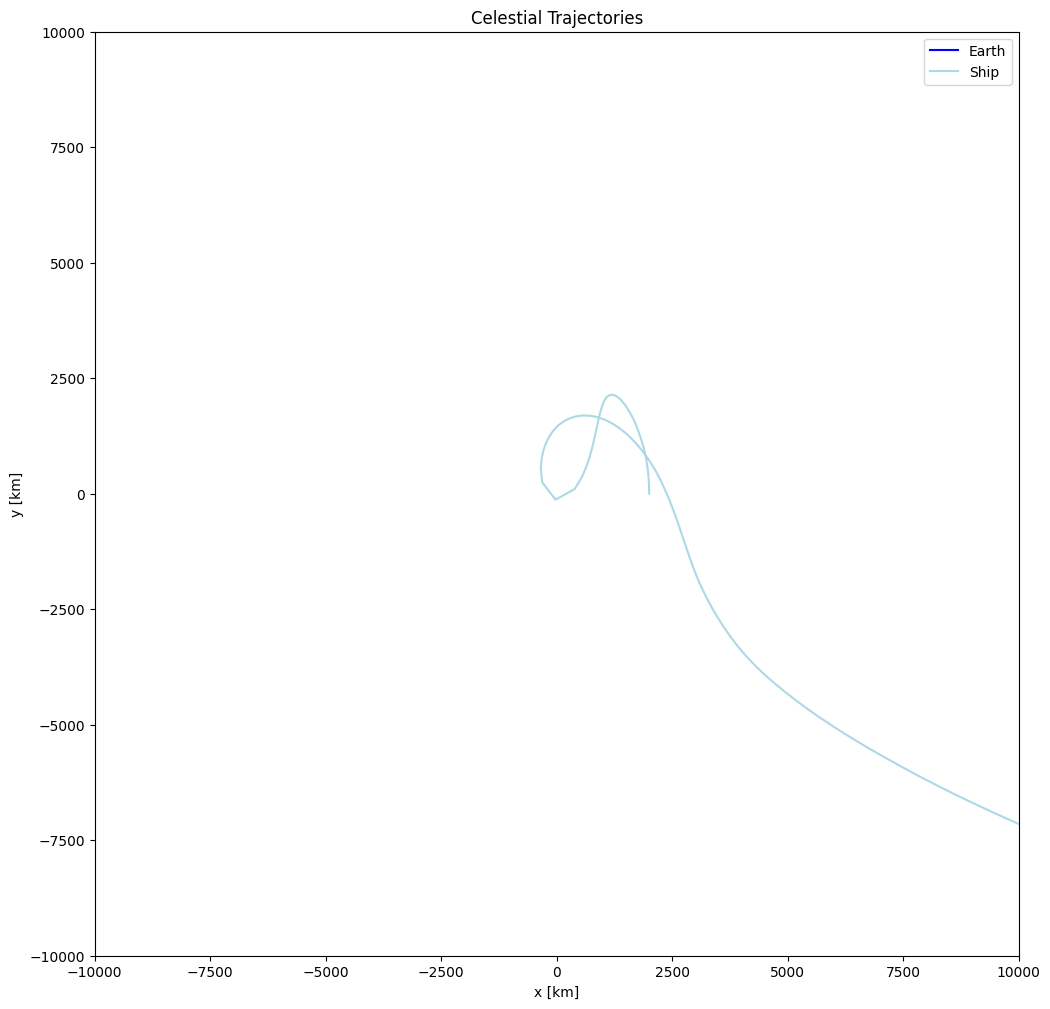

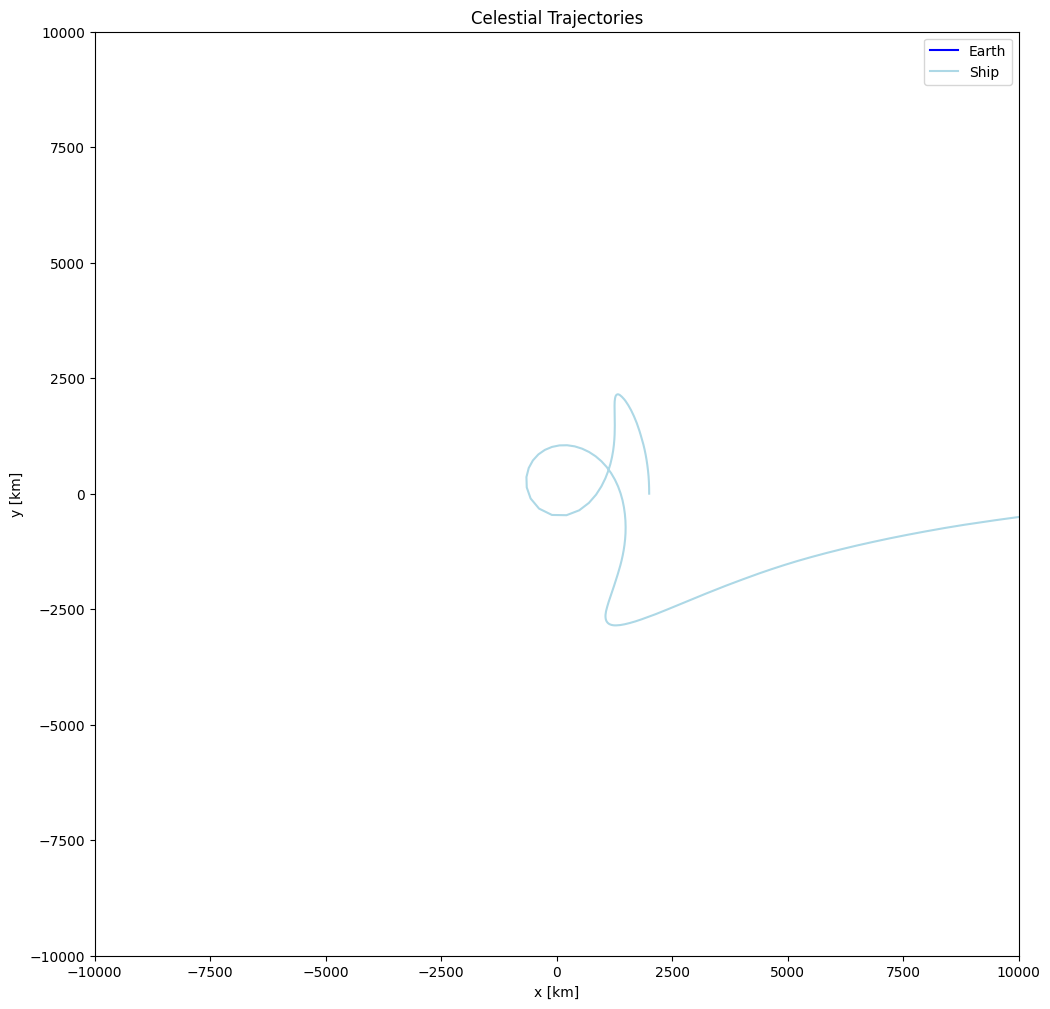

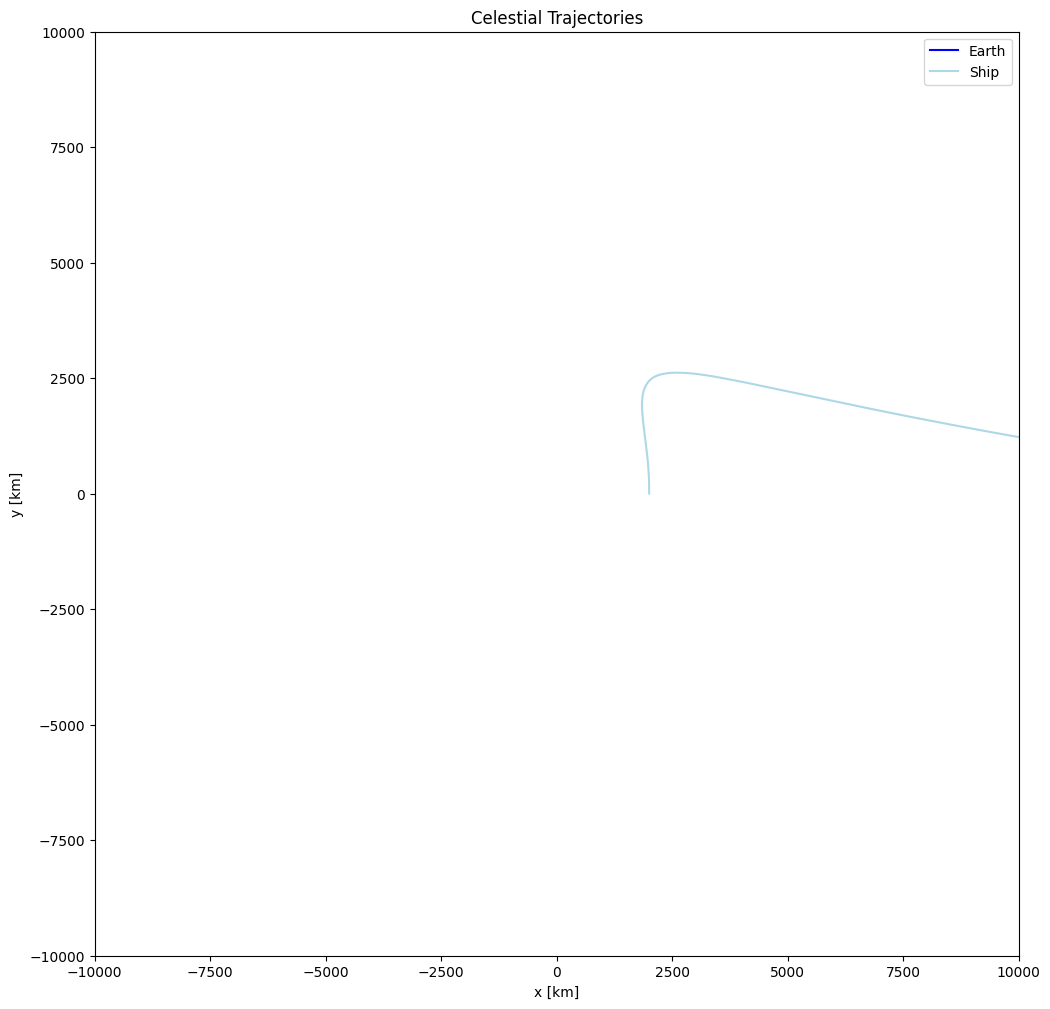

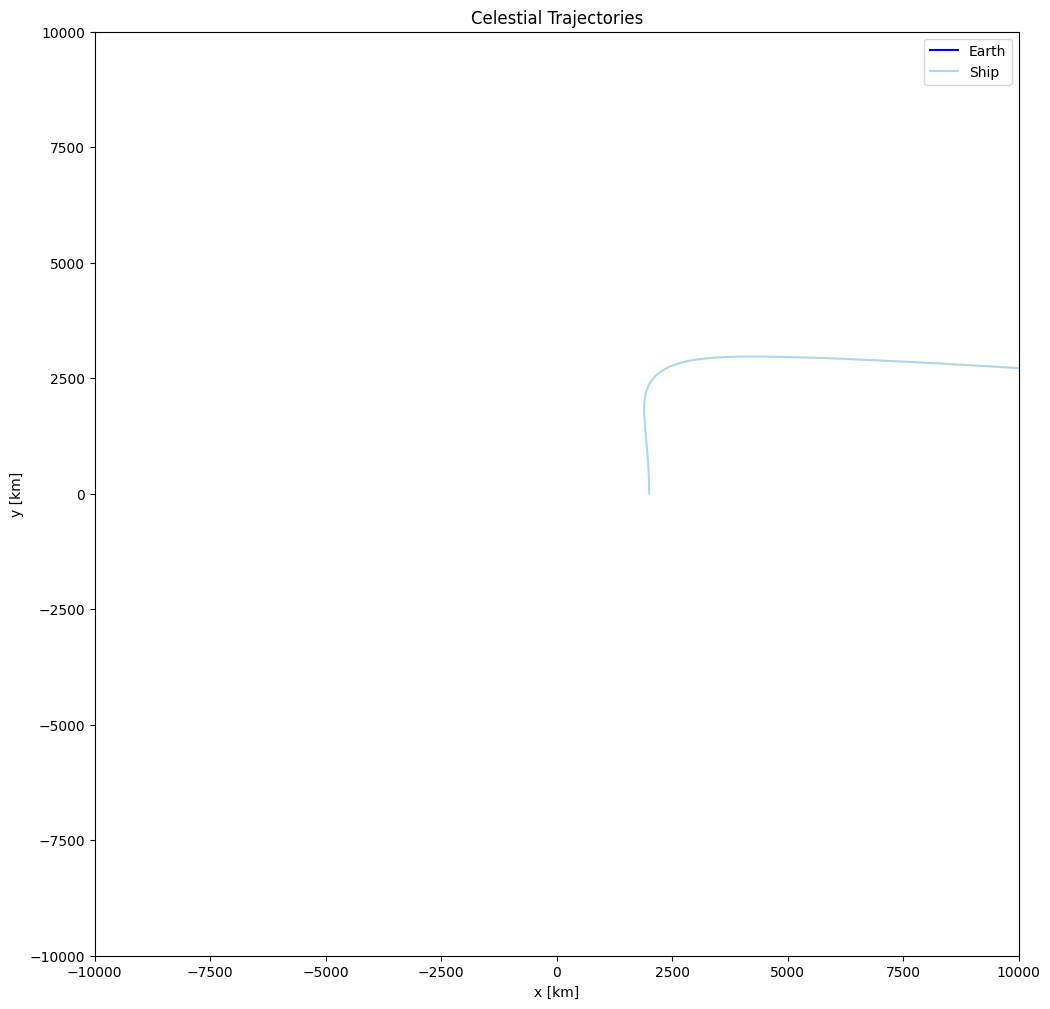

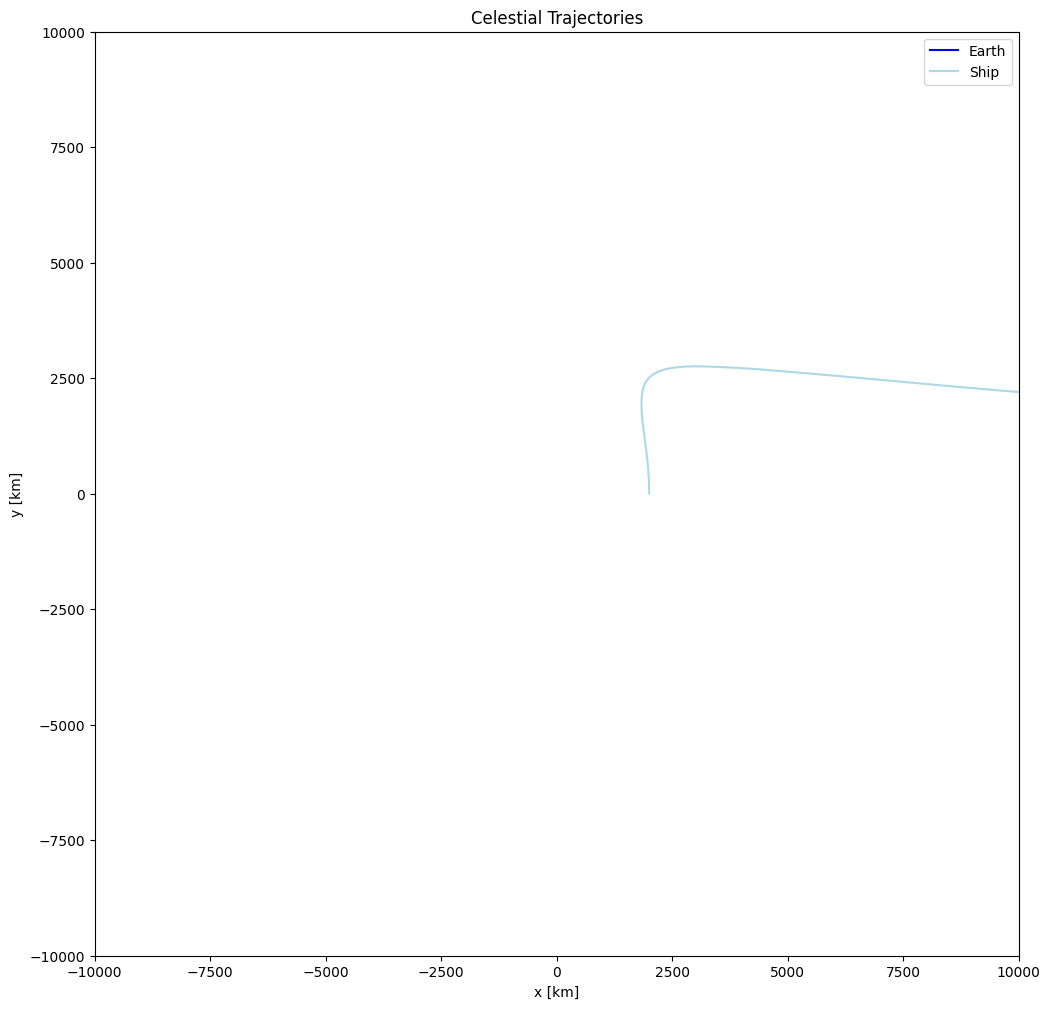

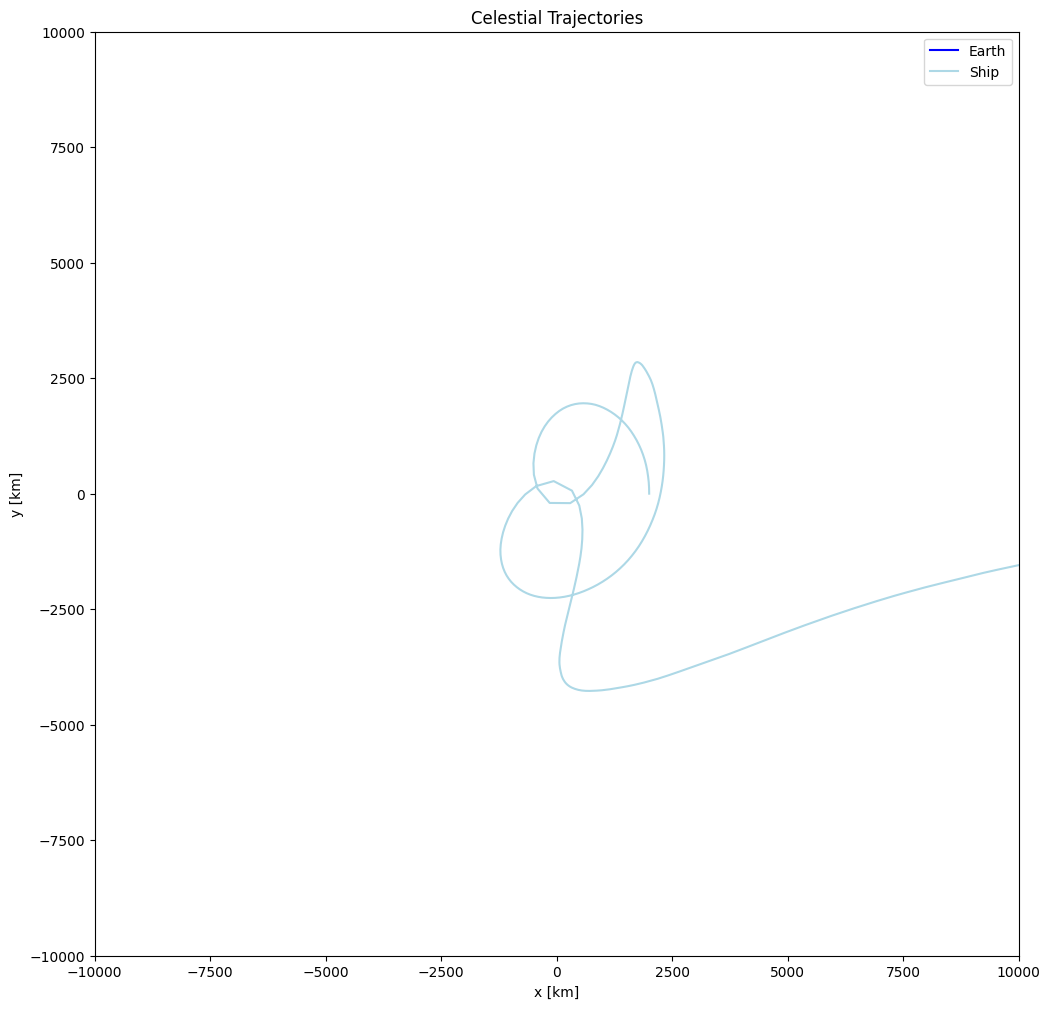

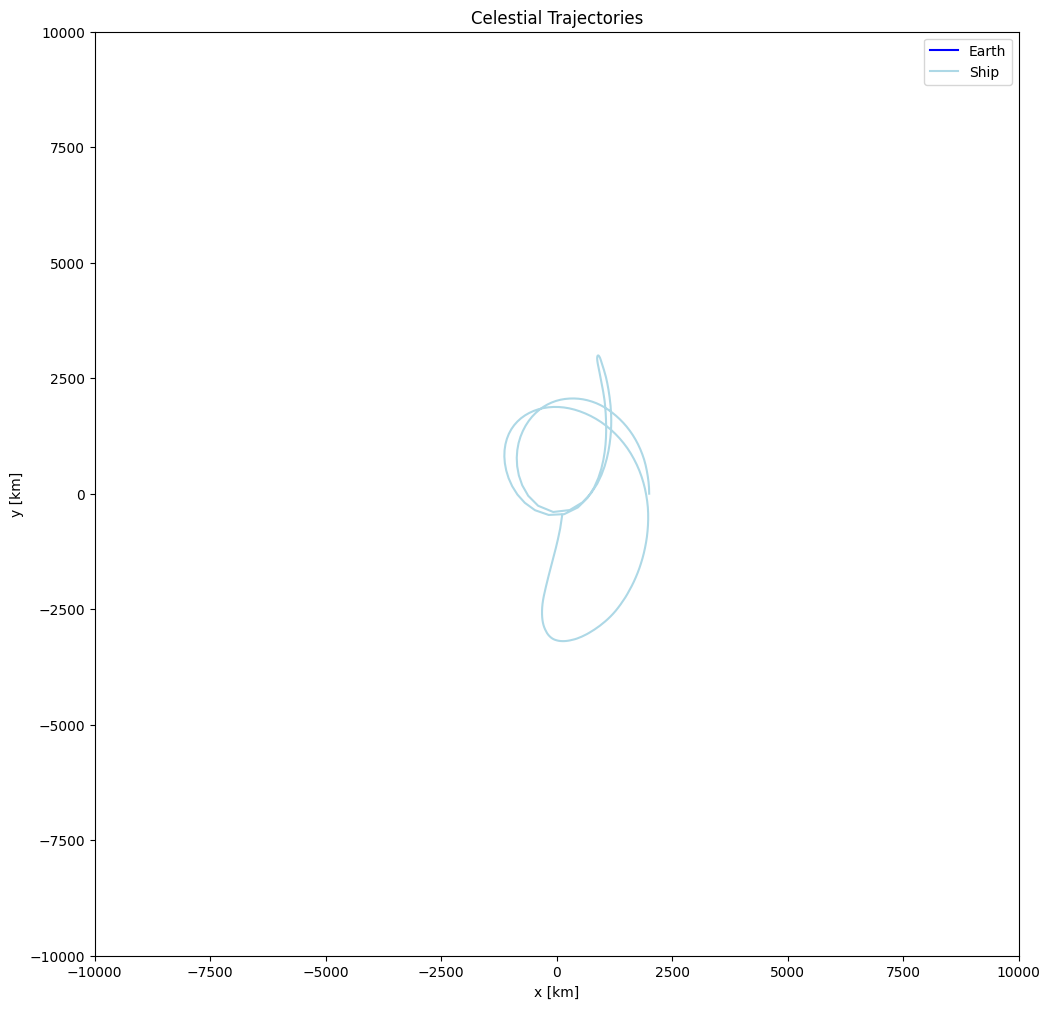

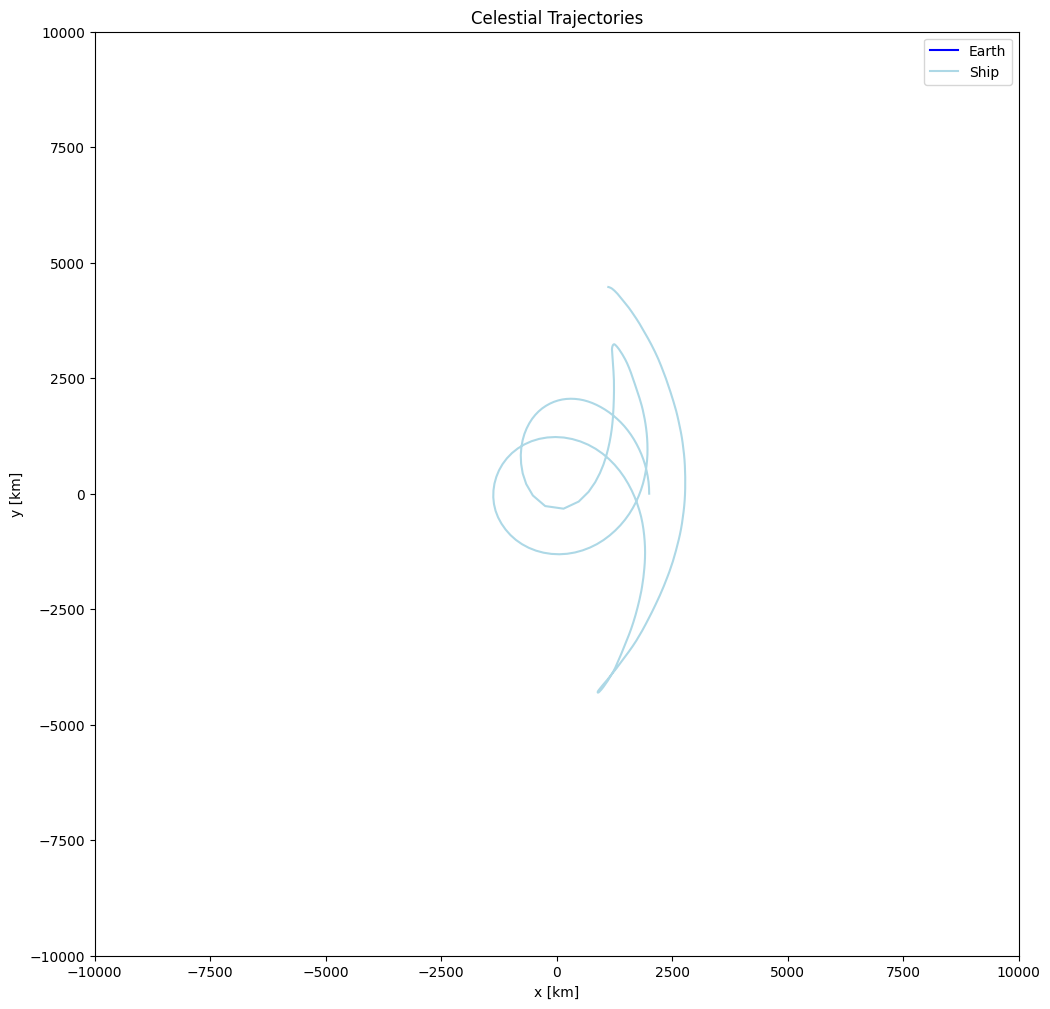

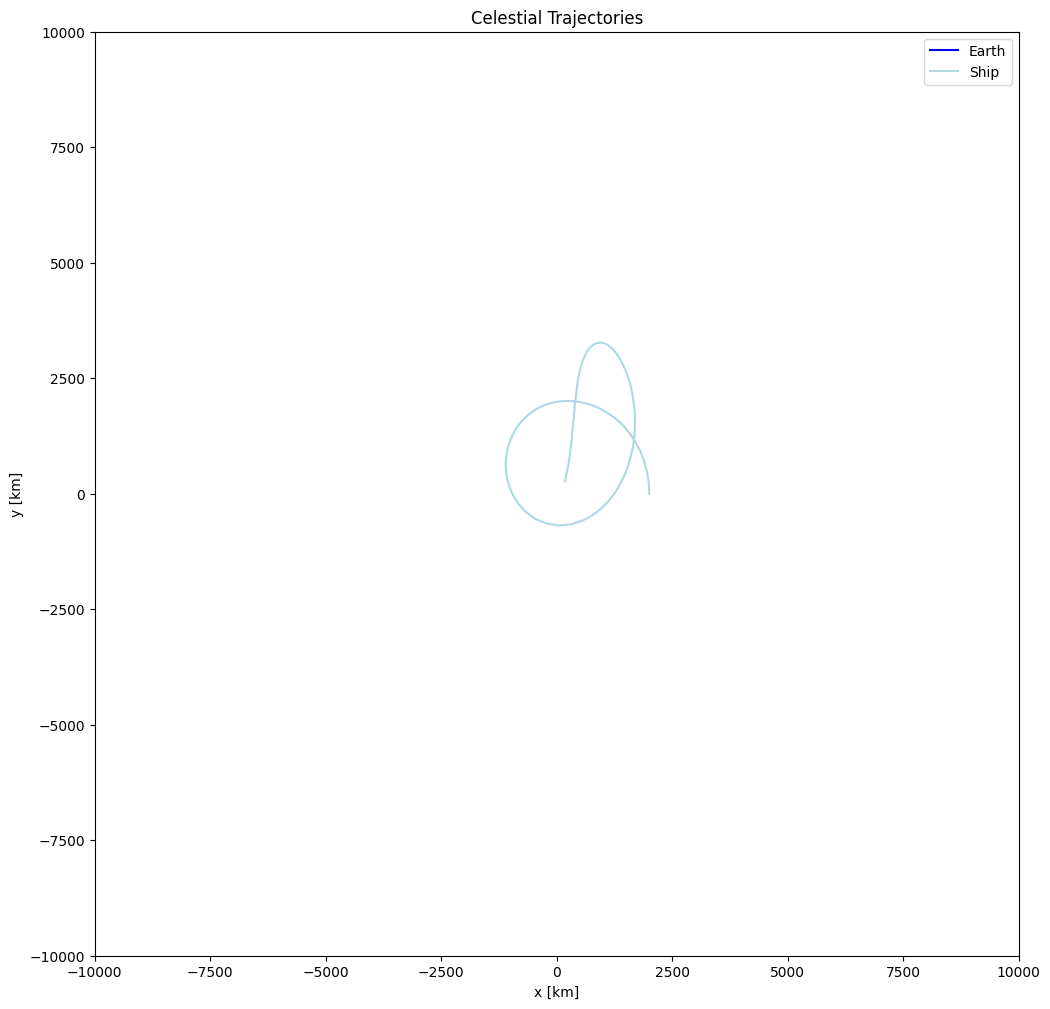

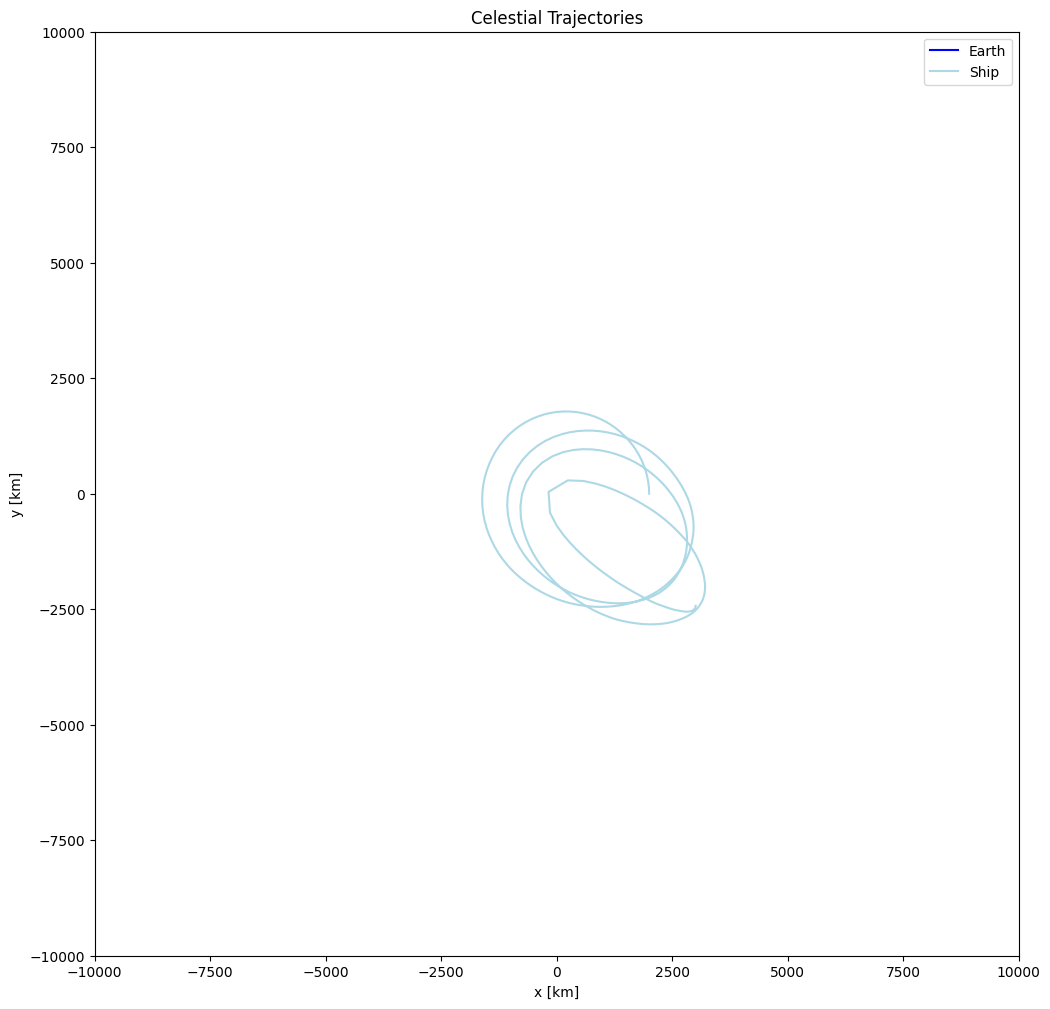

In [9]:
centre_body="Earth"
scale=1.0/1e3
xlim=(-1e4, 1e4)
ylim=(-1e4, 1e4)
xlabel="x [km]"
ylabel="y [km]"

# Folder containing episode JSON files
folder = "../../logs/training_logs/mc_800_36000_bad"

# Get all JSON files sorted
json_files = sorted([f for f in os.listdir(folder) if f.endswith(".json")])

# Iterate through each file
for fname in json_files:
    path = os.path.join(folder, fname)
    states = load_states(path)
    plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel)

In [ ]:

for states_dict in states: 
    plot_static_trajectories(states=states_dict, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel)

In [ ]:
#save_states("Training_mc_02.json", states)

In [ ]:
#anim = visualize_trajectories(states=states, body_names=bodies[3], colors=bodies[4], interval=20, scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, save_path="mcrl.gif")
#HTML(anim.to_jshtml())